# Superfiguras finalistas de la memoria

Generador único de las figuras finalistas del TFG QFS. Este notebook sustituye
cualquier intento anterior: cada figura responde una pregunta de defensa y se
construye desde tablas canónicas de `results/tables/`.

Principios aplicados:
- datos preparados con operaciones vectorizadas y agregaciones explícitas;
- títulos narrativos, no nombres de chart;
- contexto en gris y color solo cuando ayuda a leer el hallazgo;
- sin 3D, sin tartas, sin ejes secundarios;
- cada figura se guarda como PNG y PDF en
  `results/figures/superfiguras_memoria_finalistas/`;
- al final se genera un manifiesto editorial que separa las figuras de cuerpo
  de las figuras de respaldo/apéndice.

In [1]:
from __future__ import annotations

import ast
import json
import math
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TAB = ROOT / "results" / "tables"
OUT = ROOT / "results" / "figures" / "superfiguras_memoria_finalistas"
OUT.mkdir(parents=True, exist_ok=True)
MEMORIA_FIGS = ROOT / "Plantilla_Latex_GCD" / "tfgs" / "figs"

DATASETS = [
    "breast_cancer_wisconsin",
    "customer_churn",
    "madelon",
    "olive_oil_3class",
    "olive_oil_9class",
]

DLAB = {
    "breast_cancer_wisconsin": "Breast\nCancer",
    "customer_churn": "Customer\nChurn",
    "madelon": "Madelon",
    "olive_oil_3class": "Olive Oil\n3 clases",
    "olive_oil_9class": "Olive Oil\n9 clases",
}

DLAB_SHORT = {
    "breast_cancer_wisconsin": "Breast Cancer",
    "customer_churn": "Customer Churn",
    "madelon": "Madelon",
    "olive_oil_3class": "Olive 3",
    "olive_oil_9class": "Olive 9",
}

DATASET_COLORS = {
    "breast_cancer_wisconsin": "#4f81bd",
    "customer_churn": "#d9b382",
    "madelon": "#d95f5f",
    "olive_oil_3class": "#8fb7a8",
    "olive_oil_9class": "#7aa6c2",
}

METHOD_FAMILY = {
    "variance": "filtro",
    "f_classif": "filtro",
    "mutual_info": "relevancia",
    "feature_similarity": "redundancia",
    "mutual_correlation": "redundancia",
    "mrmr_approx": "combinado",
    "rrfs": "combinado",
    "linear_svm": "embedded",
    "l1_logistic": "embedded",
    "random_forest": "embedded",
    "rfe": "wrapper",
    "boruta": "wrapper",
}

FAMILY_COLORS = {
    "filtro": "#a9bfd6",
    "relevancia": "#4f81bd",
    "redundancia": "#d9b382",
    "combinado": "#c7d59f",
    "embedded": "#8fb7a8",
    "wrapper": "#d7a6a1",
}

QCOL = {
    "baseline": "#9e9e9e",
    "clasico": "#4f81bd",
    "qfs_na": "#d95f5f",
    "oraculo": "#d9b382",
    "positivo": "#4f81bd",
    "negativo": "#d95f5f",
}

BG = "#f7f4ef"
TEXT = "#333333"
GRID = "#ded9d1"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 220,
        "savefig.bbox": "tight",
        "figure.facecolor": BG,
        "axes.facecolor": BG,
        "axes.edgecolor": "#8b867d",
        "axes.labelcolor": TEXT,
        "xtick.color": TEXT,
        "ytick.color": TEXT,
        "text.color": TEXT,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.alpha": 0.7,
        "legend.frameon": False,
    }
)


def table(rel: str) -> pd.DataFrame:
    path = TAB / rel
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def maybe_table(rel: str) -> pd.DataFrame:
    path = TAB / rel
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


def save_figure(fig: mpl.figure.Figure, stem: str) -> None:
    png = OUT / f"{stem}.png"
    pdf = OUT / f"{stem}.pdf"
    fig.savefig(png)
    fig.savefig(pdf)
    print(f"guardado: {png.relative_to(ROOT)}")


def finish_axes(ax: mpl.axes.Axes) -> None:
    ax.grid(axis="x", alpha=0.55)
    ax.grid(axis="y", alpha=0.25)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color("#b7b0a6")


def panel_label(ax: mpl.axes.Axes, label: str) -> None:
    ax.text(
        -0.04,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="bottom",
        ha="right",
    )


def add_title(fig: mpl.figure.Figure, title: str, subtitle: str) -> None:
    fig.text(0.015, 0.982, title, fontsize=16, fontweight="bold", ha="left", va="top")
    fig.text(0.015, 0.948, subtitle, fontsize=10.5, ha="left", va="top", color="#5b5853")


def clean_feature(name: str, max_len: int = 28) -> str:
    name = str(name).replace("_", " ")
    if len(name) <= max_len:
        return name
    return name[: max_len - 1] + "…"


def parse_features(value) -> list[str]:
    if pd.isna(value):
        return []
    s = str(value).strip().strip("'\"")
    if "|" in s:
        return [x for x in s.split("|") if x]
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple)):
            return [str(x) for x in parsed]
    except Exception:
        pass
    return [x.strip() for x in s.split(",") if x.strip()]


def norm01(values) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    out = np.full(arr.shape, np.nan)
    mask = np.isfinite(arr)
    if not mask.any():
        return np.zeros_like(arr, dtype=float)
    lo = np.nanmin(arr[mask])
    hi = np.nanmax(arr[mask])
    if hi - lo < 1e-12:
        out[mask] = 0.5
    else:
        out[mask] = (arr[mask] - lo) / (hi - lo)
    return np.nan_to_num(out, nan=0.0)


def ds_order_labels(order=DATASETS) -> list[str]:
    return [DLAB[d] for d in order]


print(f"ROOT = {ROOT}")
print(f"OUT  = {OUT}")

ROOT = /home/gosacar/TFG - QFS Last Chance Claude
OUT  = /home/gosacar/TFG - QFS Last Chance Claude/results/figures/superfiguras_memoria_finalistas


## F01 · El banco obliga a leer por régimen

Pregunta de defensa: ¿por qué estos cinco problemas no deben promediarse como
si fueran uno solo?  
Fuente: auditoría de splits, distribución del target y resumen de asociación
con el target.  
Familia: bubble plot + barras horizontales + decisión de métrica.

guardado: results/figures/superfiguras_memoria_finalistas/F01_banco_regimenes.png


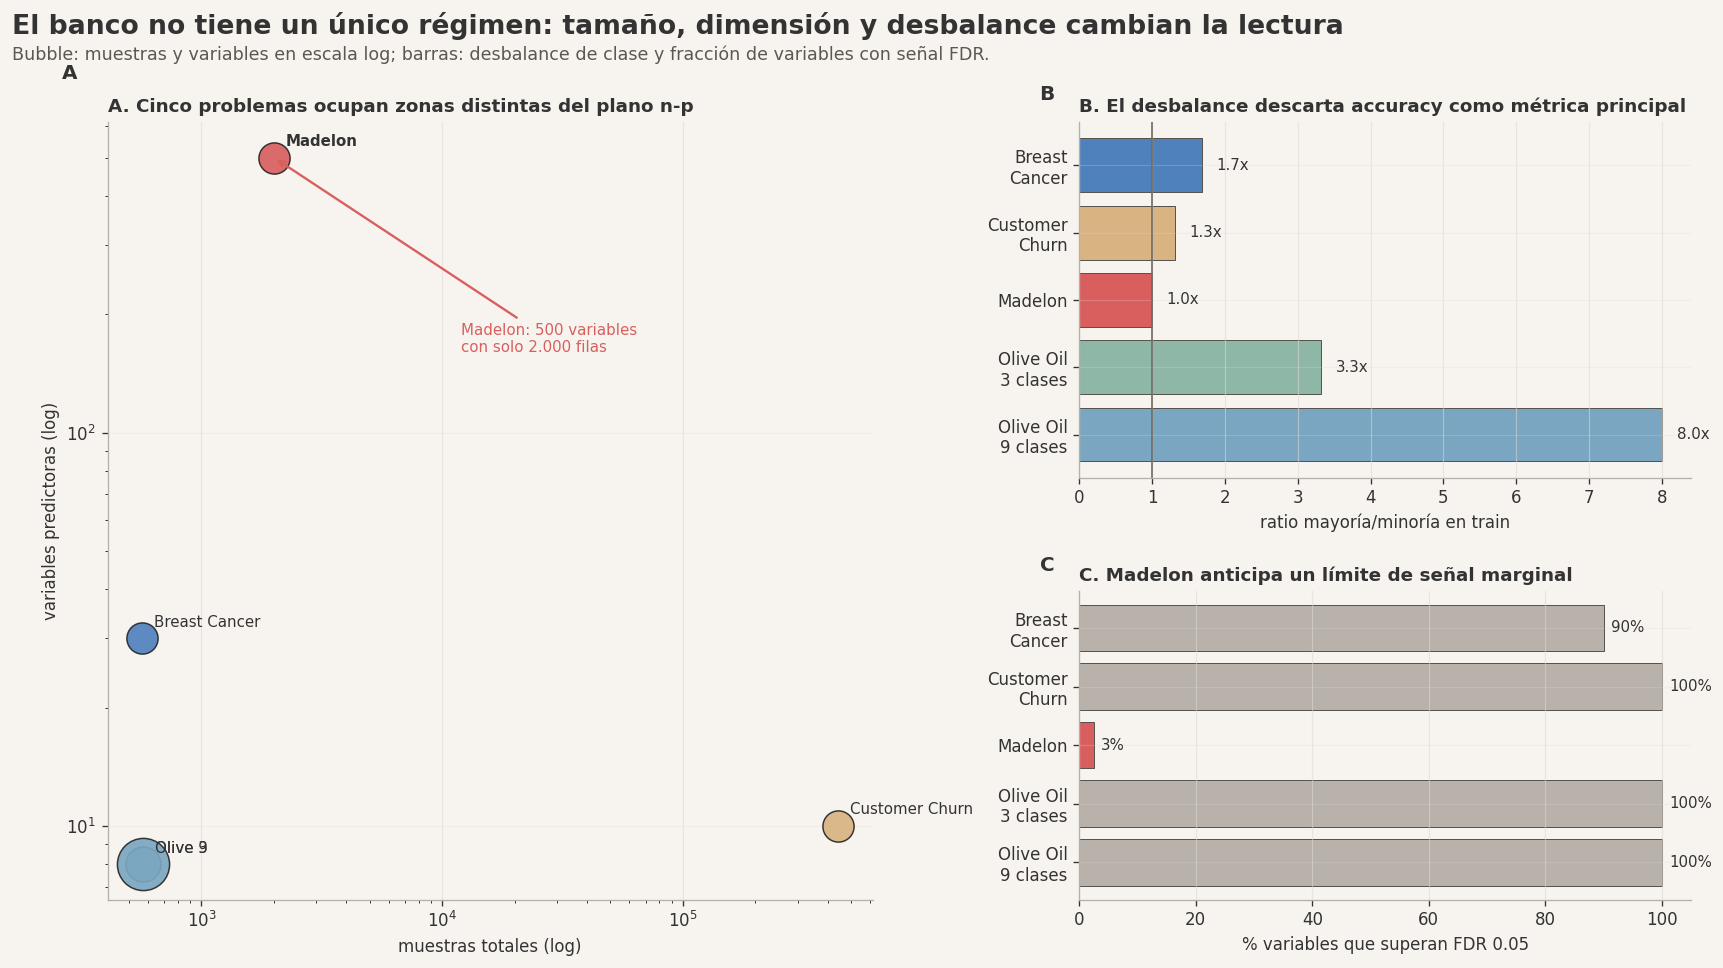

In [2]:
def figure_f01_banco() -> None:
    xy = table("04_split_audit/fase4_resumen_xy.csv")
    target = table("04_split_audit/fase4_target_distribucion.csv")
    assoc = table("01_raw_eda/fase1_asociacion_target_resumen.csv")

    # Olive se bifurca en fase 4; la señal univariante procede del origen olive_oil.
    assoc_key = {d: ("olive_oil" if d.startswith("olive_oil") else d) for d in DATASETS}

    rows = []
    for ds in DATASETS:
        xyr = xy.loc[xy["dataset"] == ds].iloc[0]
        train = target[(target["dataset"] == ds) & (target["split"] == "train")]
        if train.empty:
            train = target[target["dataset"] == ds]
        proportions = train["proporcion"].to_numpy(float)
        imbalance = float(proportions.max() / proportions.min()) if len(proportions) > 1 else 1.0
        ar = assoc.loc[assoc["dataset"] == assoc_key[ds]]
        effect = float(ar["efecto_abs_mediano"].iloc[0]) if not ar.empty else np.nan
        fdr = float(ar["variables_fdr_005"].iloc[0]) if not ar.empty else np.nan
        tested = float(ar["variables_contrastadas"].iloc[0]) if not ar.empty else np.nan
        rows.append(
            {
                "dataset": ds,
                "filas": xyr["filas"],
                "features": xyr["features"],
                "clases": xyr["target_clases"],
                "imbalance": imbalance,
                "effect": effect,
                "fdr_ratio": fdr / tested if tested else np.nan,
            }
        )
    df = pd.DataFrame(rows)

    fig = plt.figure(figsize=(14.5, 8.2), constrained_layout=False)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1], width_ratios=[1.25, 1], hspace=0.34, wspace=0.30)
    add_title(
        fig,
        "El banco no tiene un único régimen: tamaño, dimensión y desbalance cambian la lectura",
        "Bubble: muestras y variables en escala log; barras: desbalance de clase y fracción de variables con señal FDR.",
    )

    ax = fig.add_subplot(gs[:, 0])
    for _, r in df.iterrows():
        ds = r["dataset"]
        size = 170 + 90 * float(r["clases"])
        ax.scatter(
            r["filas"],
            r["features"],
            s=size,
            color=DATASET_COLORS[ds],
            edgecolor="#262626",
            linewidth=0.9,
            alpha=0.92,
            zorder=3,
        )
        ax.annotate(
            DLAB_SHORT[ds],
            (r["filas"], r["features"]),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold" if ds == "madelon" else "normal",
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("muestras totales (log)")
    ax.set_ylabel("variables predictoras (log)")
    ax.set_title("A. Cinco problemas ocupan zonas distintas del plano n-p", loc="left")
    ax.annotate(
        "Madelon: 500 variables\ncon solo 2.000 filas",
        xy=(2000, 500),
        xytext=(12000, 160),
        arrowprops=dict(arrowstyle="->", color=QCOL["negativo"], lw=1.4),
        color=QCOL["negativo"],
        fontsize=9,
    )
    finish_axes(ax)
    panel_label(ax, "A")

    order = DATASETS[::-1]
    y = np.arange(len(order))

    ax = fig.add_subplot(gs[0, 1])
    vals = [df.loc[df.dataset == ds, "imbalance"].iloc[0] for ds in order]
    colors = [DATASET_COLORS[ds] for ds in order]
    ax.barh(y, vals, color=colors, edgecolor="#57534e", linewidth=0.6)
    for yi, val in zip(y, vals):
        ax.text(val + max(vals) * 0.025, yi, f"{val:.1f}x", va="center", fontsize=9)
    ax.axvline(1, color="#6f6a62", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(ds_order_labels(order))
    ax.set_xlabel("ratio mayoría/minoría en train")
    ax.set_title("B. El desbalance descarta accuracy como métrica principal", loc="left")
    finish_axes(ax)
    panel_label(ax, "B")

    ax = fig.add_subplot(gs[1, 1])
    vals = [100 * df.loc[df.dataset == ds, "fdr_ratio"].iloc[0] for ds in order]
    colors = [QCOL["negativo"] if ds == "madelon" else "#b8b2aa" for ds in order]
    ax.barh(y, vals, color=colors, edgecolor="#57534e", linewidth=0.6)
    for yi, val in zip(y, vals):
        ax.text(val + 1.2, yi, f"{val:.0f}%", va="center", fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(ds_order_labels(order))
    ax.set_xlim(0, 105)
    ax.set_xlabel("% variables que superan FDR 0.05")
    ax.set_title("C. Madelon anticipa un límite de señal marginal", loc="left")
    finish_axes(ax)
    panel_label(ax, "C")

    fig.subplots_adjust(top=0.87, left=0.07, right=0.98, bottom=0.08)
    save_figure(fig, "F01_banco_regimenes")
    plt.show()


figure_f01_banco()

## F02 · La señal es real, pero Madelon apenas es univariante

Pregunta de defensa: ¿dónde hay señal supervisada y dónde no?  
Fuente: `fase1_asociacion_target_resumen.csv`.  
Familia: Cleveland/dot plot en dos paneles para separar recuento y magnitud.

guardado: results/figures/superfiguras_memoria_finalistas/F02_senal_fdr_efecto.png


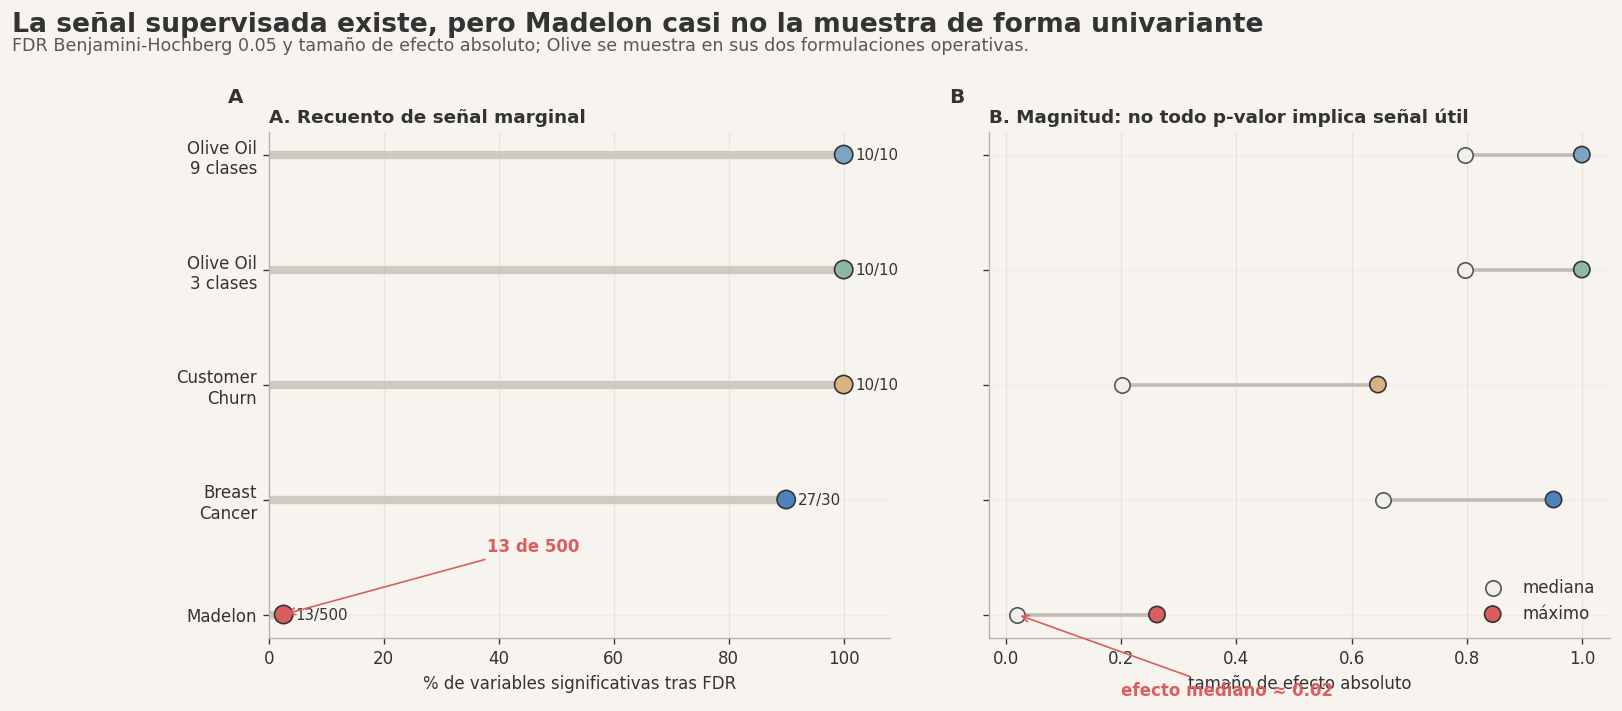

In [3]:
def figure_f02_senal() -> None:
    assoc = table("01_raw_eda/fase1_asociacion_target_resumen.csv").copy()
    olive = assoc.loc[assoc["dataset"] == "olive_oil"].iloc[0].copy()
    rows = []
    for ds in DATASETS:
        src = "olive_oil" if ds.startswith("olive_oil") else ds
        r = assoc.loc[assoc["dataset"] == src].iloc[0]
        rows.append(
            {
                "dataset": ds,
                "tested": r["variables_contrastadas"],
                "fdr": r["variables_fdr_005"],
                "ratio": r["variables_fdr_005"] / r["variables_contrastadas"],
                "median_effect": r["efecto_abs_mediano"],
                "max_effect": r["efecto_abs_maximo"],
            }
        )
    df = pd.DataFrame(rows)
    order = df.sort_values("ratio", ascending=True)["dataset"].tolist()
    y = np.arange(len(order))

    fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.2), sharey=True)
    add_title(
        fig,
        "La señal supervisada existe, pero Madelon casi no la muestra de forma univariante",
        "FDR Benjamini-Hochberg 0.05 y tamaño de efecto absoluto; Olive se muestra en sus dos formulaciones operativas.",
    )

    ax = axes[0]
    vals = [100 * df.loc[df.dataset == ds, "ratio"].iloc[0] for ds in order]
    cols = [QCOL["negativo"] if ds == "madelon" else DATASET_COLORS[ds] for ds in order]
    ax.hlines(y, 0, vals, color="#c8c0b7", lw=5, alpha=0.8)
    ax.scatter(vals, y, s=120, color=cols, edgecolor="#333333", zorder=3)
    for yi, ds, val in zip(y, order, vals):
        row = df.loc[df.dataset == ds].iloc[0]
        ax.text(val + 2, yi, f"{int(row.fdr)}/{int(row.tested)}", va="center", fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(ds_order_labels(order))
    ax.set_xlim(0, 108)
    ax.set_xlabel("% de variables significativas tras FDR")
    ax.set_title("A. Recuento de señal marginal", loc="left")
    ax.annotate(
        "13 de 500",
        xy=(vals[order.index("madelon")], order.index("madelon")),
        xytext=(38, order.index("madelon") + 0.55),
        arrowprops=dict(arrowstyle="->", color=QCOL["negativo"]),
        color=QCOL["negativo"],
        fontweight="bold",
    )
    finish_axes(ax)
    panel_label(ax, "A")

    ax = axes[1]
    med = [df.loc[df.dataset == ds, "median_effect"].iloc[0] for ds in order]
    mx = [df.loc[df.dataset == ds, "max_effect"].iloc[0] for ds in order]
    ax.hlines(y, med, mx, color="#bdb6ad", lw=2.2, alpha=0.9)
    ax.scatter(med, y, s=85, color="#f1efe9", edgecolor="#555", label="mediana", zorder=3)
    ax.scatter(mx, y, s=95, color=cols, edgecolor="#333", label="máximo", zorder=4)
    ax.set_xlabel("tamaño de efecto absoluto")
    ax.set_title("B. Magnitud: no todo p-valor implica señal útil", loc="left")
    ax.legend(loc="lower right")
    ax.annotate(
        "efecto mediano ≈ 0.02",
        xy=(med[order.index("madelon")], order.index("madelon")),
        xytext=(0.20, order.index("madelon") - 0.7),
        arrowprops=dict(arrowstyle="->", color=QCOL["negativo"]),
        color=QCOL["negativo"],
        fontweight="bold",
    )
    finish_axes(ax)
    panel_label(ax, "B")

    fig.subplots_adjust(top=0.82, left=0.17, right=0.98, bottom=0.14, wspace=0.16)
    save_figure(fig, "F02_senal_fdr_efecto")
    plt.show()


figure_f02_senal()

## F03 · La base experimental queda auditada antes de modelar

Pregunta de defensa: ¿particiones, drift y preprocesado contaminan la
comparación?  
Fuente: validación adversarial, drift de split y conservación de rankings MI.  
Familia: tres paneles con bandas/umbrales.

guardado: results/figures/superfiguras_memoria_finalistas/F03_base_confiable.png


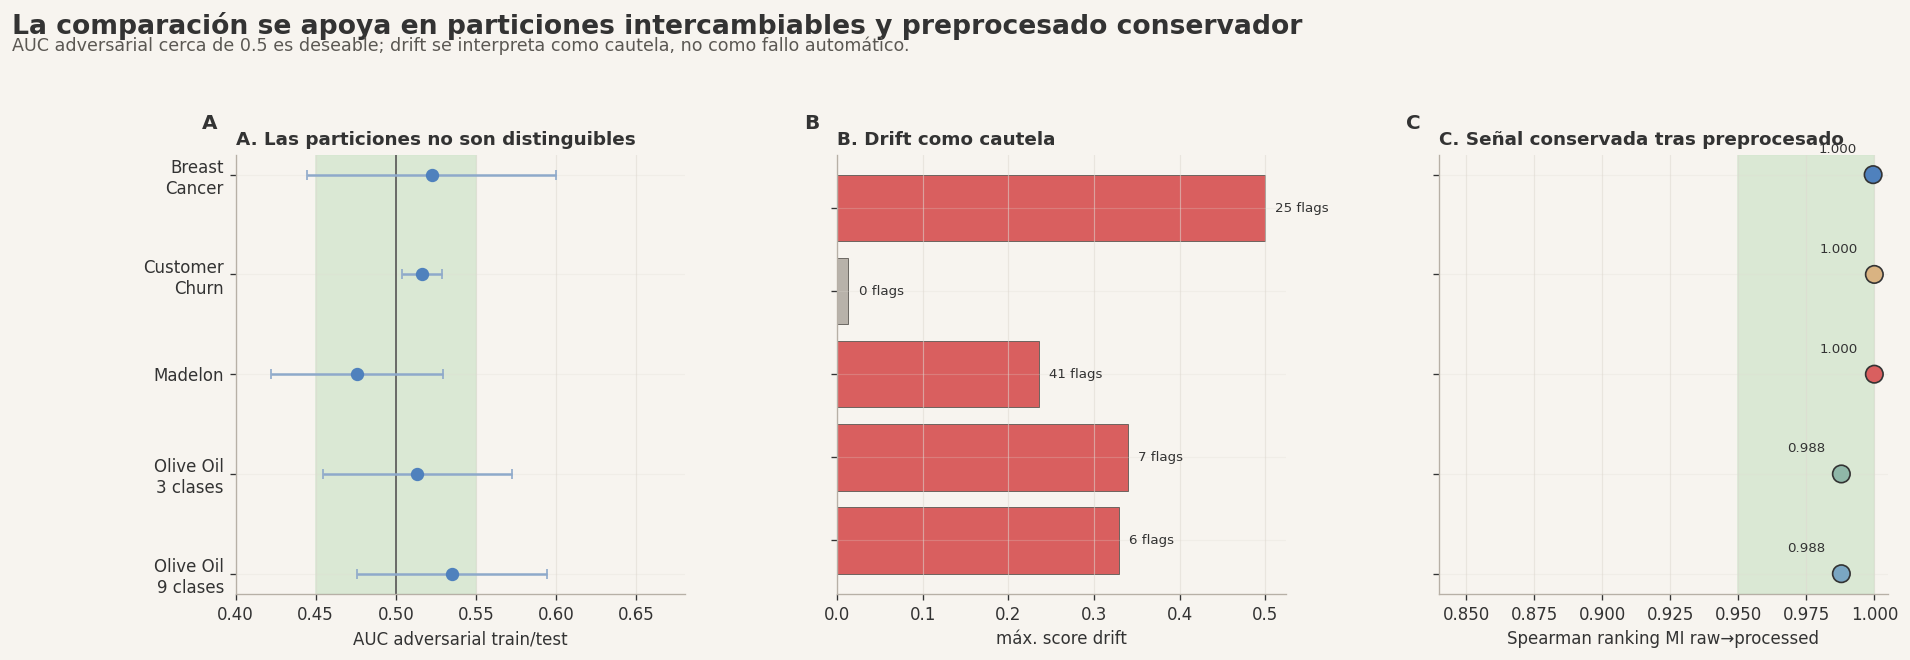

In [4]:
def figure_f03_base_confiable() -> None:
    adv = table("04_split_audit/fase4_validacion_adversarial.csv")
    drift = table("04_split_audit/fase4_drift_resumen.csv")
    assoc = table("03_postprocessing_audit/fase3_asociacion_tests.csv")

    # Olive se audita como origen en fase 3; se replica en ambas formulaciones.
    assoc_rows = {}
    for ds in DATASETS:
        src = "olive_oil" if ds.startswith("olive_oil") else ds
        row = assoc.loc[assoc["dataset"] == src]
        assoc_rows[ds] = float(row["spearman_rankings_raw_processed"].iloc[0]) if not row.empty else np.nan

    fig, axes = plt.subplots(1, 3, figsize=(16.2, 5.9))
    add_title(
        fig,
        "La comparación se apoya en particiones intercambiables y preprocesado conservador",
        "AUC adversarial cerca de 0.5 es deseable; drift se interpreta como cautela, no como fallo automático.",
    )

    order = DATASETS[::-1]
    y = np.arange(len(order))

    ax = axes[0]
    auc = [adv.loc[adv.dataset == ds, "auc_cv"].iloc[0] for ds in order]
    err = [adv.loc[adv.dataset == ds, "auc_fold_std"].iloc[0] for ds in order]
    ax.axvspan(0.45, 0.55, color="#d7e7d2", alpha=0.9, label="banda 0.45-0.55")
    ax.errorbar(auc, y, xerr=err, fmt="o", color=QCOL["positivo"], ecolor="#8ea9ca", ms=7, capsize=3, zorder=3)
    ax.axvline(0.5, color="#555", lw=1)
    ax.set_xlim(0.40, 0.68)
    ax.set_yticks(y)
    ax.set_yticklabels(ds_order_labels(order))
    ax.set_xlabel("AUC adversarial train/test")
    ax.set_title("A. Las particiones no son distinguibles", loc="left")
    finish_axes(ax)
    panel_label(ax, "A")

    ax = axes[1]
    flags = [drift.loc[drift.dataset == ds, "variables_con_flag"].iloc[0] for ds in order]
    mx = [drift.loc[drift.dataset == ds, "max_drift_score"].iloc[0] for ds in order]
    colors = [QCOL["negativo"] if f > 0 else "#b8b2aa" for f in flags]
    ax.barh(y, mx, color=colors, edgecolor="#5b5853", linewidth=0.5)
    for yi, f, val in zip(y, flags, mx):
        ax.text(val + 0.012, yi, f"{int(f)} flags", va="center", fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels([])
    ax.set_xlabel("máx. score drift")
    ax.set_title("B. Drift como cautela", loc="left")
    finish_axes(ax)
    panel_label(ax, "B")

    ax = axes[2]
    sp = [assoc_rows[ds] for ds in order]
    ax.axvspan(0.95, 1.0, color="#d7e7d2", alpha=0.9)
    ax.scatter(sp, y, s=110, color=[DATASET_COLORS[ds] for ds in order], edgecolor="#333", zorder=3)
    for yi, val in zip(y, sp):
        ax.text(val - 0.006, yi + 0.22, f"{val:.3f}", ha="right", fontsize=8)
    ax.set_xlim(0.84, 1.005)
    ax.set_yticks(y)
    ax.set_yticklabels([])
    ax.set_xlabel("Spearman ranking MI raw→processed")
    ax.set_title("C. Señal conservada tras preprocesado", loc="left")
    finish_axes(ax)
    panel_label(ax, "C")

    fig.subplots_adjust(top=0.78, left=0.13, right=0.98, bottom=0.16, wspace=0.34)
    save_figure(fig, "F03_base_confiable")
    plt.show()


figure_f03_base_confiable()

## F04 · Los selectores tienen perfiles distintos antes de competir en test

Pregunta de defensa: ¿qué aporta cada familia de selección?  
Fuente: perfiles agregados, estabilidad Jaccard y permutaciones.  
Familia: insignia 2x2 con orden compartido.

guardado: results/figures/superfiguras_memoria_finalistas/F04_perfil_selectores.png


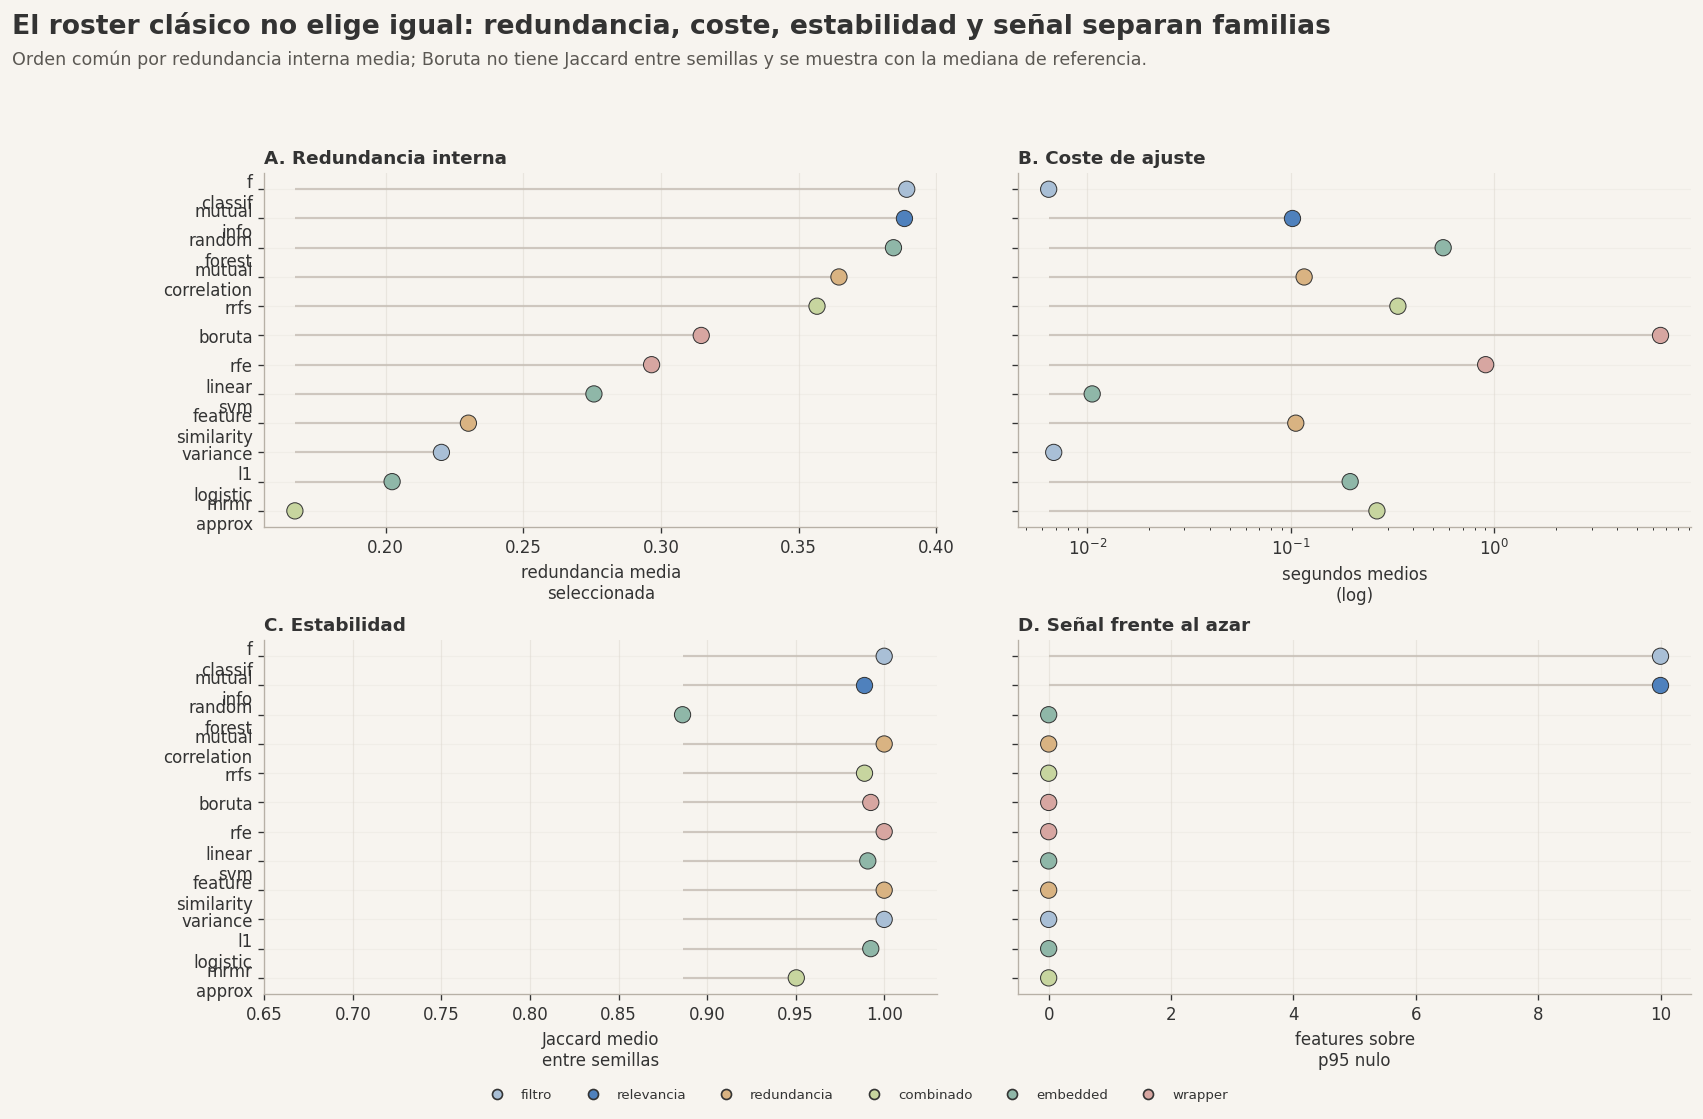

In [5]:
def figure_f04_selectores() -> None:
    profiles = table("05_feature_selection/fs_method_profiles.csv").copy()
    perm = table("05_feature_selection/fs_permutation_summary.csv")
    profiles["family"] = profiles["method"].map(METHOD_FAMILY).fillna("otro")
    profiles["jaccard_plot"] = profiles["jaccard_medio"].fillna(profiles["jaccard_medio"].median())
    perm_summary = perm.groupby("method", as_index=False)["n_features_above_null"].median()
    profiles = profiles.merge(perm_summary, on="method", how="left")
    profiles["n_features_above_null"] = profiles["n_features_above_null"].fillna(0)
    profiles = profiles.sort_values(["corr_media_seleccionada", "segundos_medios"], ascending=[True, True]).reset_index(drop=True)
    methods = profiles["method"].tolist()
    y = np.arange(len(methods))
    colors = [FAMILY_COLORS.get(f, "#bbb") for f in profiles["family"]]

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.5), sharey=True)
    add_title(
        fig,
        "El roster clásico no elige igual: redundancia, coste, estabilidad y señal separan familias",
        "Orden común por redundancia interna media; Boruta no tiene Jaccard entre semillas y se muestra con la mediana de referencia.",
    )

    panels = [
        ("corr_media_seleccionada", "redundancia media\nseleccionada", "A. Redundancia interna"),
        ("segundos_medios", "segundos medios\n(log)", "B. Coste de ajuste"),
        ("jaccard_plot", "Jaccard medio\nentre semillas", "C. Estabilidad"),
        ("n_features_above_null", "features sobre\np95 nulo", "D. Señal frente al azar"),
    ]
    for ax, (col, xlabel, title) in zip(axes.flat, panels):
        vals = profiles[col].to_numpy(float)
        ax.scatter(vals, y, s=95, c=colors, edgecolor="#333333", linewidth=0.6, zorder=3)
        ax.hlines(y, np.nanmin(vals), vals, color="#c8c0b7", lw=1.3, alpha=0.85)
        ax.set_title(title, loc="left")
        ax.set_xlabel(xlabel)
        ax.set_yticks(y)
        ax.set_yticklabels([m.replace("_", "\n") for m in methods])
        if col == "segundos_medios":
            ax.set_xscale("log")
        if col == "jaccard_plot":
            ax.set_xlim(0.65, 1.03)
        finish_axes(ax)
    for ax in axes[:, 1]:
        ax.tick_params(labelleft=False)

    handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=c, markeredgecolor="#333", label=f)
        for f, c in FAMILY_COLORS.items()
    ]
    fig.legend(handles=handles, ncol=6, loc="lower center", bbox_to_anchor=(0.5, 0.015), fontsize=8)
    fig.subplots_adjust(top=0.84, left=0.16, right=0.98, bottom=0.12, hspace=0.32, wspace=0.12)
    save_figure(fig, "F04_perfil_selectores")
    plt.show()


figure_f04_selectores()

## F05 · La frontera de parsimonia muestra cuánto se puede reducir

Pregunta de defensa: ¿menos variables mantiene o mejora rendimiento?  
Fuente: `modeling_cost_performance.csv`.  
Familia: small multiples con frontera de Pareto y línea de no pérdida.

guardado: results/figures/superfiguras_memoria_finalistas/F05_frontera_coste_rendimiento.png


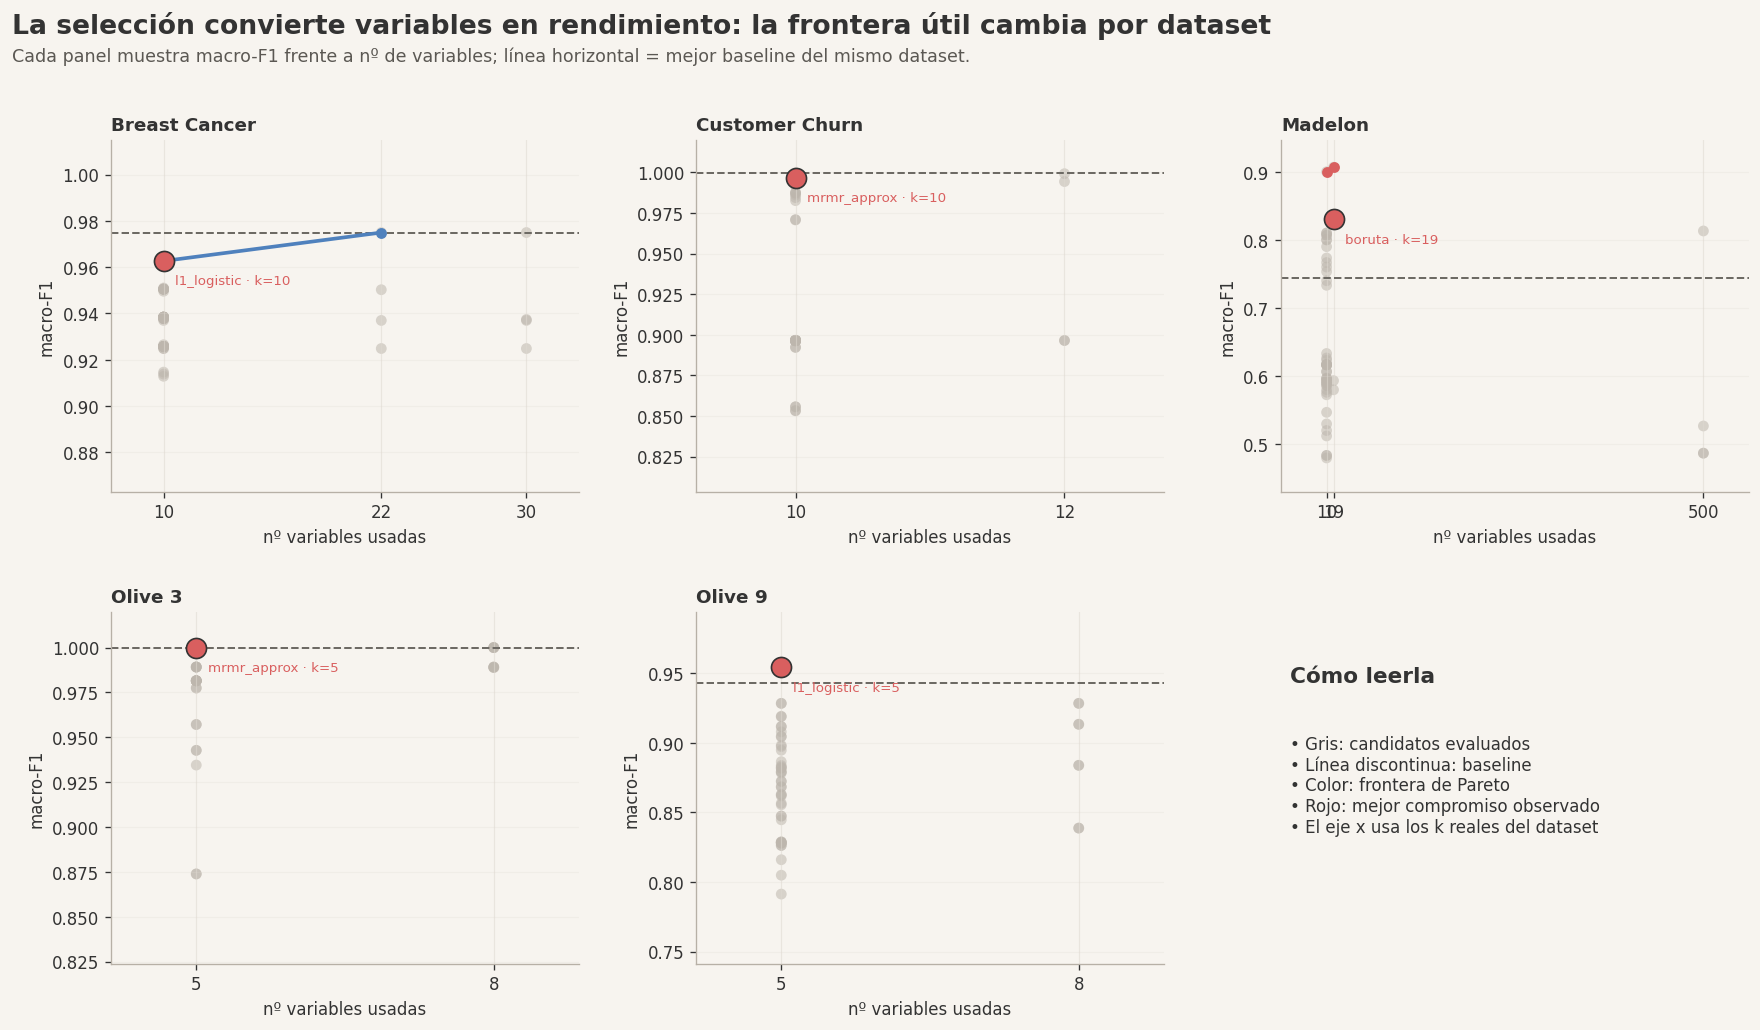

In [6]:
def pareto_front(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    work = df.sort_values([x_col, y_col], ascending=[True, False]).copy()
    best = -np.inf
    keep = []
    for _, row in work.iterrows():
        yv = float(row[y_col])
        if yv > best + 1e-12:
            keep.append(True)
            best = yv
        else:
            keep.append(False)
    return work.loc[keep]


def figure_f05_coste_rendimiento() -> None:
    cost = table("06_modeling/modeling_cost_performance.csv").copy()
    cost = cost[np.isfinite(cost["test_macro_f1"].fillna(cost["macro_f1"]))].copy()
    cost["score"] = cost["test_macro_f1"].fillna(cost["macro_f1"])
    cost["delta"] = cost["score"] - cost["baseline_macro_f1_same_model"]
    cost["family"] = cost["selector"].map(METHOD_FAMILY).fillna("otro")

    fig, axes = plt.subplots(2, 3, figsize=(15, 8.8), sharey=False)
    add_title(
        fig,
        "La selección convierte variables en rendimiento: la frontera útil cambia por dataset",
        "Cada panel muestra macro-F1 frente a nº de variables; línea horizontal = mejor baseline del mismo dataset.",
    )

    axes_flat = axes.flat
    for i, ds in enumerate(DATASETS):
        ax = axes_flat[i]
        sub = cost[cost["dataset"] == ds].copy()
        baseline = float(sub["baseline_macro_f1_same_model"].max())
        ax.axhline(baseline, color="#6d6a64", lw=1.2, ls="--", label="baseline")
        ax.scatter(
            sub["n_features_used"],
            sub["score"],
            s=42,
            color="#bdb6ad",
            alpha=0.55,
            edgecolor="none",
        )
        front = pareto_front(sub, "n_features_used", "score")
        ax.plot(front["n_features_used"], front["score"], "-o", color=DATASET_COLORS[ds], lw=2.2, ms=5.5, zorder=4)
        best = sub.sort_values(["delta", "feature_reduction_ratio"], ascending=[False, False]).head(1).iloc[0]
        ax.scatter(best["n_features_used"], best["score"], s=145, color=QCOL["negativo"], edgecolor="#333", zorder=5)
        ax.annotate(
            f"{best['selector']} · k={int(best['n_features_used'])}",
            (best["n_features_used"], best["score"]),
            xytext=(7, -14),
            textcoords="offset points",
            fontsize=8,
            color=QCOL["negativo"],
        )
        unique_x = np.array(sorted(sub["n_features_used"].dropna().unique()), dtype=float)
        if len(unique_x) <= 5:
            ax.set_xticks(unique_x)
            ax.set_xticklabels([str(int(x)) for x in unique_x])
            span = max(1.0, unique_x.max() - unique_x.min())
            ax.set_xlim(unique_x.min() - 0.12 * span - 0.5, unique_x.max() + 0.12 * span + 0.5)
        elif unique_x.max() / max(unique_x.min(), 1) > 6:
            ax.set_xscale("log")
        else:
            shown = np.unique(np.round(np.linspace(unique_x.min(), unique_x.max(), 4)).astype(int))
            ax.set_xticks(shown)
            ax.set_xticklabels([str(x) for x in shown])
        ax.set_title(DLAB_SHORT[ds], loc="left")
        ax.set_xlabel("nº variables usadas")
        ax.set_ylabel("macro-F1")
        ax.set_ylim(max(0, sub["score"].min() - 0.05), min(1.02, sub["score"].max() + 0.04))
        finish_axes(ax)
    axes_flat[5].axis("off")
    axes_flat[5].text(
        0.02,
        0.80,
        "Cómo leerla",
        fontsize=13,
        fontweight="bold",
        transform=axes_flat[5].transAxes,
    )
    axes_flat[5].text(
        0.02,
        0.65,
        "• Gris: candidatos evaluados\n"
        "• Línea discontinua: baseline\n"
        "• Color: frontera de Pareto\n"
        "• Rojo: mejor compromiso observado\n"
        "• El eje x usa los k reales del dataset",
        fontsize=10,
        va="top",
        transform=axes_flat[5].transAxes,
    )
    fig.subplots_adjust(top=0.86, left=0.07, right=0.98, bottom=0.08, hspace=0.34, wspace=0.25)
    save_figure(fig, "F05_frontera_coste_rendimiento")
    plt.show()


figure_f05_coste_rendimiento()

## F06 · SHAP por instancia muestra impacto, no solo ranking

Pregunta de defensa: ¿qué variables sostienen el modelo y con qué dirección
local?  
Fuente: matrices SHAP crudas y valores de feature para Breast Cancer, Customer
Churn y Madelon.  
Familia: beeswarm manual, con muestra visual etiquetada.

guardado: results/figures/superfiguras_memoria_finalistas/F06_shap_beeswarm_instancias.png


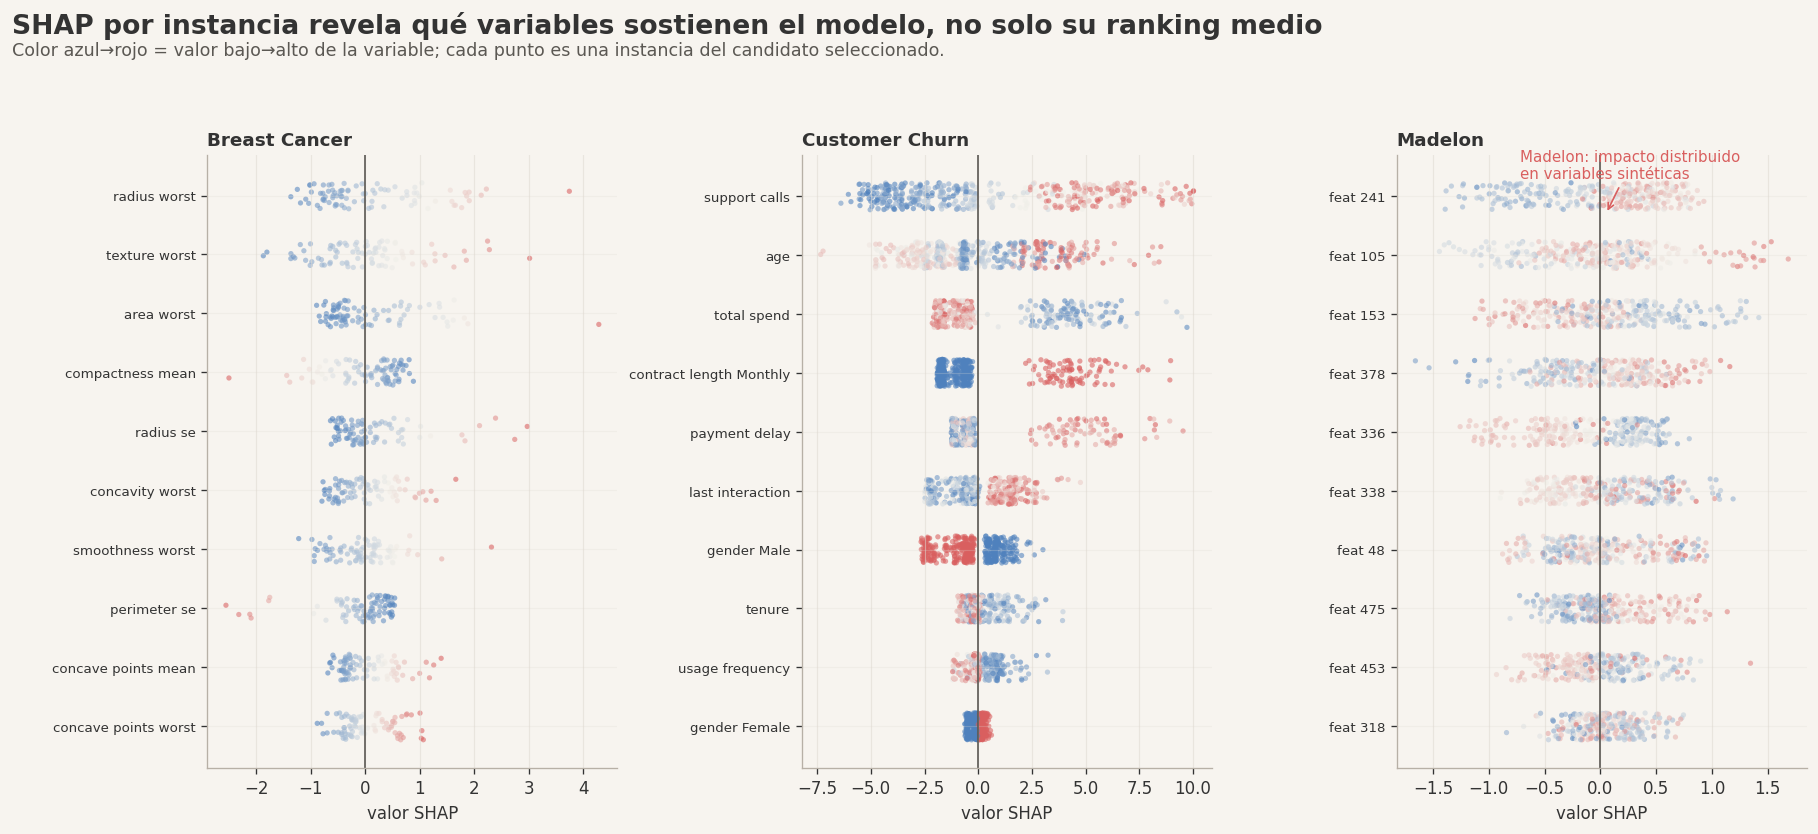

In [7]:
def best_shap_pair(dataset: str) -> tuple[Path, Path]:
    full = sorted((TAB / "06_modeling").glob(f"modeling_shap_values_full_{dataset}__*.csv"))
    if not full:
        raise FileNotFoundError(dataset)
    # Preferir subconjunto seleccionado frente a all_features para legibilidad.
    candidates = [p for p in full if "__all_features__" not in p.name] or full
    shap_path = candidates[0]
    value_name = shap_path.name.replace("modeling_shap_values_full_", "modeling_shap_feature_values_")
    value_path = shap_path.with_name(value_name)
    if not value_path.exists():
        value_path = sorted((TAB / "06_modeling").glob(f"modeling_shap_feature_values_{dataset}__*.csv"))[0]
    return shap_path, value_path


def beeswarm_panel(ax: mpl.axes.Axes, dataset: str, max_features: int = 10, max_points: int = 450) -> None:
    shap_path, val_path = best_shap_pair(dataset)
    shap = pd.read_csv(shap_path)
    vals = pd.read_csv(val_path)
    feature_cols = [c for c in shap.columns if c != "row_position"]
    importance = shap[feature_cols].abs().mean().sort_values(ascending=False)
    top = importance.head(max_features).index.tolist()
    n = min(max_points, len(shap))
    idx = np.linspace(0, len(shap) - 1, n).astype(int)
    cmap = LinearSegmentedColormap.from_list("qfs_shap", ["#4f81bd", "#f1efe9", "#d95f5f"])

    for yi, feat in enumerate(top[::-1]):
        x = shap.loc[idx, feat].to_numpy(float)
        raw = vals.loc[idx, feat].to_numpy(float) if feat in vals else np.zeros_like(x)
        raw_n = norm01(raw)
        jitter = (np.random.default_rng(1234 + yi).random(len(x)) - 0.5) * 0.46
        ax.scatter(x, yi + jitter, c=raw_n, cmap=cmap, s=10, alpha=0.58, edgecolor="none", rasterized=True)
    ax.axvline(0, color="#5b5853", lw=1)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([clean_feature(f, 24) for f in top[::-1]], fontsize=8)
    ax.set_title(DLAB_SHORT[dataset], loc="left")
    ax.set_xlabel("valor SHAP")
    ax.grid(axis="y", alpha=0)
    finish_axes(ax)


def figure_f06_shap() -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 7.4), sharex=False)
    add_title(
        fig,
        "SHAP por instancia revela qué variables sostienen el modelo, no solo su ranking medio",
        "Color azul→rojo = valor bajo→alto de la variable; cada punto es una instancia del candidato seleccionado.",
    )
    for ax, ds in zip(axes, ["breast_cancer_wisconsin", "customer_churn", "madelon"]):
        beeswarm_panel(ax, ds)
    axes[2].annotate(
        "Madelon: impacto distribuido\nen variables sintéticas",
        xy=(0.05, 8.7),
        xycoords=("data", "data"),
        xytext=(0.30, 9.3),
        textcoords=("axes fraction", "data"),
        arrowprops=dict(arrowstyle="->", color=QCOL["negativo"]),
        color=QCOL["negativo"],
        fontsize=9,
    )
    fig.subplots_adjust(top=0.82, left=0.12, right=0.98, bottom=0.13, wspace=0.45)
    save_figure(fig, "F06_shap_beeswarm_instancias")
    plt.show()


figure_f06_shap()

## F07 · Significancia y magnitud no cuentan lo mismo

Pregunta de defensa: ¿cuándo una diferencia frente al baseline es afirmable?  
Fuente: comparación final clásica y tests pareados.  
Familia: forest plot de delta con umbral práctico.

guardado: results/figures/superfiguras_memoria_finalistas/F07_significancia_magnitud.png


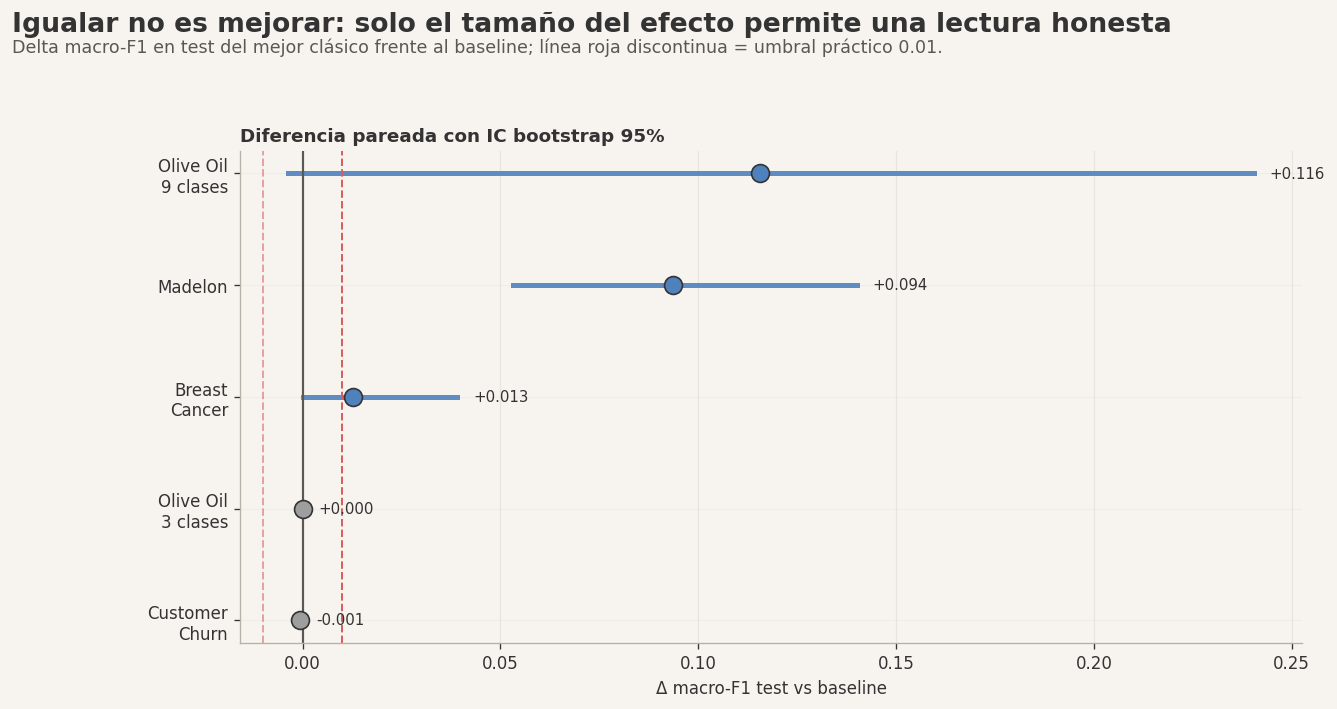

In [8]:
def figure_f07_significancia() -> None:
    final = table("07_final_comparison/fase7_comparacion_final.csv").copy()
    final["relevante"] = np.where(final["delta_test_macro_f1"] > 0.01, "mejora relevante", "sin mejora práctica")
    order = final.sort_values("delta_test_macro_f1")["dataset"].tolist()
    y = np.arange(len(order))

    fig, ax = plt.subplots(figsize=(11.5, 6.4))
    add_title(
        fig,
        "Igualar no es mejorar: solo el tamaño del efecto permite una lectura honesta",
        "Delta macro-F1 en test del mejor clásico frente al baseline; línea roja discontinua = umbral práctico 0.01.",
    )
    for yi, ds in zip(y, order):
        r = final.loc[final.dataset == ds].iloc[0]
        delta = r["delta_test_macro_f1"]
        lo, hi = r["delta_ci_low"], r["delta_ci_high"]
        col = QCOL["positivo"] if delta > 0.01 else (QCOL["negativo"] if delta < -0.01 else "#9e9e9e")
        ax.plot([lo, hi], [yi, yi], color=col, lw=3, alpha=0.9)
        ax.scatter(delta, yi, s=115, color=col, edgecolor="#333", zorder=3)
        ax.text(hi + 0.004, yi, f"{delta:+.3f}", va="center", fontsize=9)
    ax.axvline(0, color="#5b5853", lw=1.3)
    ax.axvline(0.01, color=QCOL["negativo"], lw=1.2, ls="--")
    ax.axvline(-0.01, color=QCOL["negativo"], lw=1.2, ls="--", alpha=0.55)
    ax.set_yticks(y)
    ax.set_yticklabels(ds_order_labels(order))
    ax.set_xlabel("Δ macro-F1 test vs baseline")
    ax.set_title("Diferencia pareada con IC bootstrap 95%", loc="left")
    ax.annotate(
        "umbral práctico",
        xy=(0.01, len(order) - 0.35),
        xytext=(0.025, len(order) - 0.2),
        arrowprops=dict(arrowstyle="->", color=QCOL["negativo"]),
        color=QCOL["negativo"],
        fontsize=9,
    )
    finish_axes(ax)
    fig.subplots_adjust(top=0.80, left=0.18, right=0.95, bottom=0.16)
    save_figure(fig, "F07_significancia_magnitud")
    plt.show()


figure_f07_significancia()

## F08 · Los mandos de QFS: alpha fija tamaño y beta reordena densidades

Pregunta de defensa: ¿qué hacen los parámetros del módulo QFS?  
Fuente: oráculos exactos por alpha y runs de densidad por beta.  
Familia: escalera + heatmap.

guardado: results/figures/superfiguras_memoria_finalistas/F08_mandos_qfs_alpha_beta.png


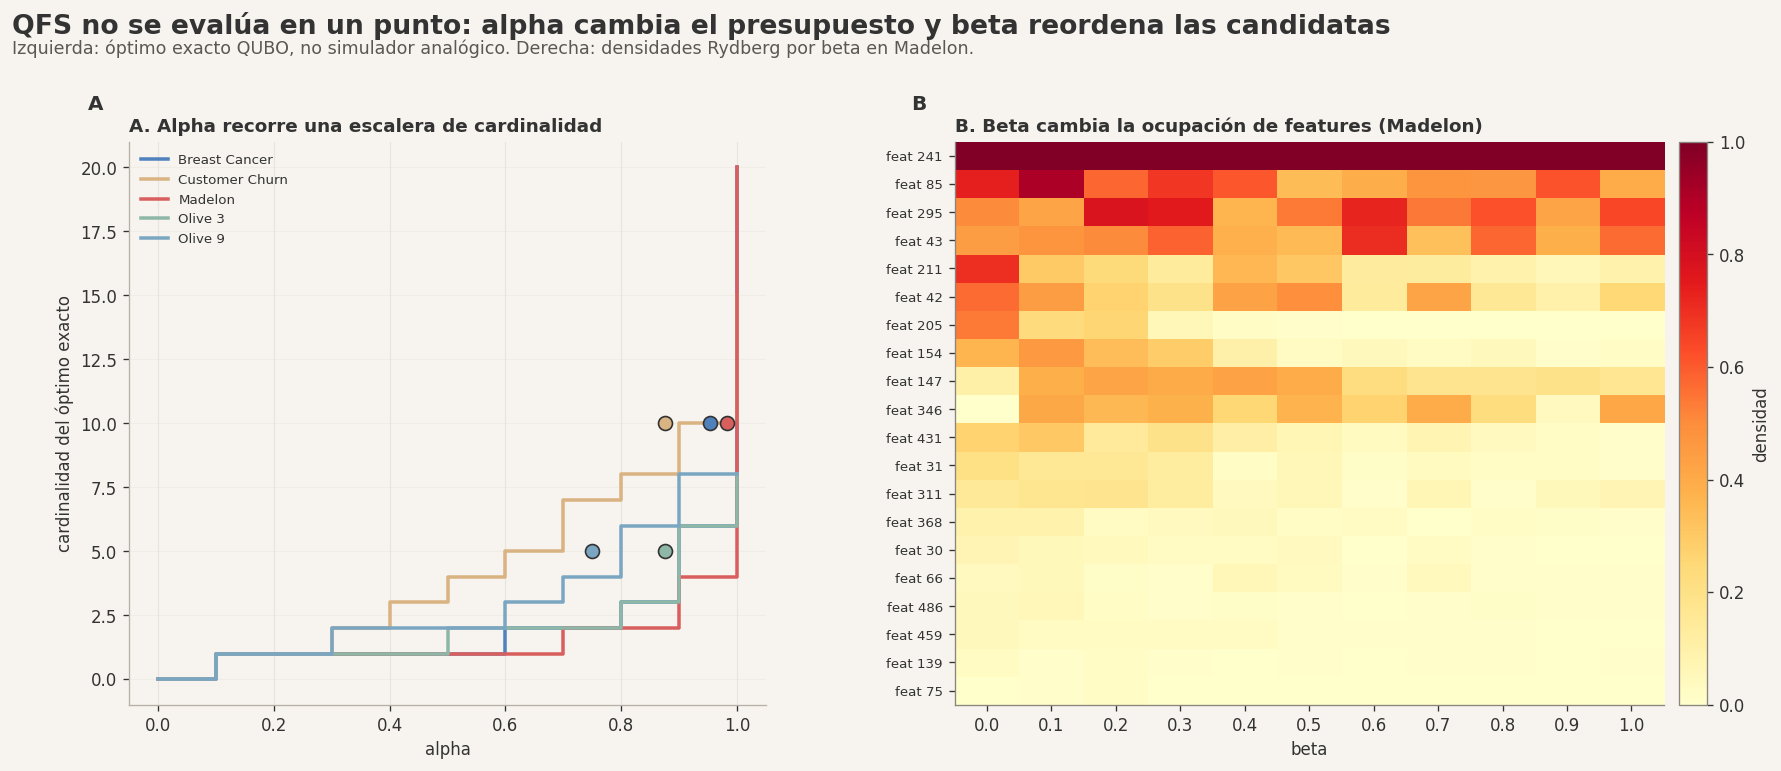

In [9]:
def qfs_density_matrix(dataset: str) -> tuple[np.ndarray, list[str], list[float]]:
    mats = []
    betas = []
    features = None
    for path in sorted((TAB / "08_quantum").glob(f"qfs_runs_{dataset}_*.csv")):
        df = pd.read_csv(path)
        beta = float(df["beta"].iloc[0])
        dens_cols = [c for c in df.columns if c.startswith("density__")]
        if features is None:
            features = [c.replace("density__", "") for c in dens_cols]
        # Las densidades son constantes por run para cada beta; mediana robusta.
        mats.append(df[dens_cols].median().to_numpy(float))
        betas.append(beta)
    return np.vstack(mats).T, features or [], betas


def figure_f08_mandos_qfs() -> None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.7), gridspec_kw={"width_ratios": [1.05, 1.25]})
    add_title(
        fig,
        "QFS no se evalúa en un punto: alpha cambia el presupuesto y beta reordena las candidatas",
        "Izquierda: óptimo exacto QUBO, no simulador analógico. Derecha: densidades Rydberg por beta en Madelon.",
    )

    ax = axes[0]
    for ds in DATASETS:
        oracle = table(f"08_quantum/qfs_oracle_{ds}.csv")
        grid = oracle[oracle["mode"] == "alpha_grid"].sort_values("alpha")
        ax.step(grid["alpha"], grid["cardinality"], where="post", lw=2.1, color=DATASET_COLORS[ds], label=DLAB_SHORT[ds])
        target = oracle[oracle["mode"] != "alpha_grid"]
        if not target.empty:
            ax.scatter(target["alpha"], target["cardinality"], s=70, color=DATASET_COLORS[ds], edgecolor="#333", zorder=4)
    ax.set_xlabel("alpha")
    ax.set_ylabel("cardinalidad del óptimo exacto")
    ax.set_title("A. Alpha recorre una escalera de cardinalidad", loc="left")
    ax.legend(fontsize=8, loc="upper left", ncol=1)
    finish_axes(ax)
    panel_label(ax, "A")

    ax = axes[1]
    mat, feats, betas = qfs_density_matrix("madelon")
    order = np.argsort(-mat.max(axis=1))[:20]
    mat = mat[order]
    feats = [feats[i] for i in order]
    im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(betas)))
    ax.set_xticklabels([f"{b:.1f}" for b in betas], rotation=0)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([clean_feature(f, 18) for f in feats], fontsize=8)
    ax.set_xlabel("beta")
    ax.set_title("B. Beta cambia la ocupación de features (Madelon)", loc="left")
    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label("densidad")
    ax.grid(False)
    panel_label(ax, "B")

    fig.subplots_adjust(top=0.82, left=0.08, right=0.96, bottom=0.12, wspace=0.27)
    save_figure(fig, "F08_mandos_qfs_alpha_beta")
    plt.show()


figure_f08_mandos_qfs()

## F09 · Dos deterioros distintos: criterio frente a optimizador

Pregunta de defensa: cuando QFS se deteriora, ¿qué falla?  
Fuente: comparación QFS-NA/oráculo frente a baseline.  
Familia: plano de atribución en puntos de macro-F1.

guardado: results/figures/superfiguras_memoria_finalistas/F09_atribucion_criterio_optimizador.png


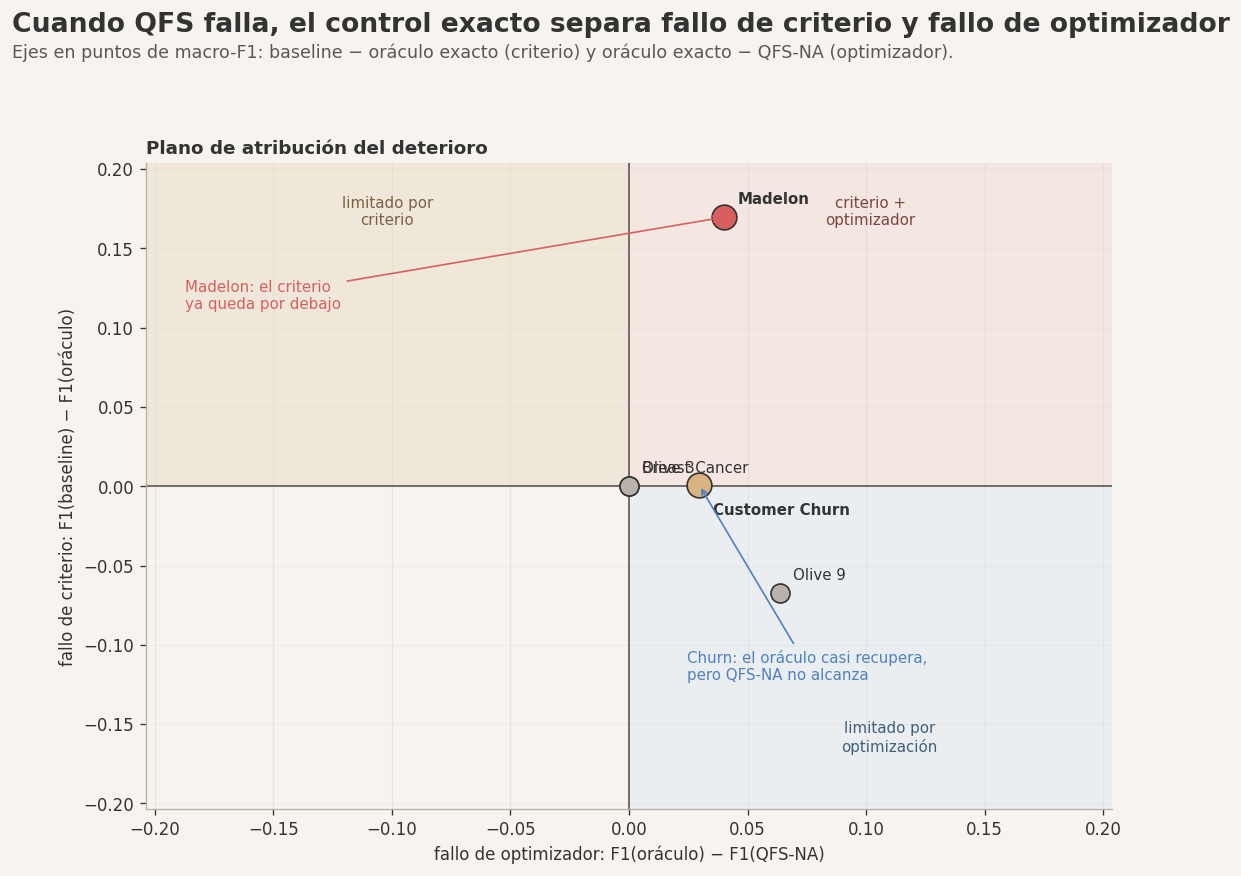

In [10]:
def figure_f09_atribucion() -> None:
    comp = table("08_quantum/comparacion_qfs_configuraciones_vs_baseline.csv")
    rows = []
    for ds in DATASETS:
        na = comp[(comp["dataset"] == ds) & (comp["configuration"] == "qfs_na")]
        oracle = comp[(comp["dataset"] == ds) & (comp["configuration"] == "qfs_oracle_mucke")]
        if na.empty or oracle.empty:
            continue
        na = na.iloc[0]
        oracle = oracle.iloc[0]
        baseline = float(na["baseline_test_macro_f1"])
        qfs = float(na["qfs_test_macro_f1"])
        opt = float(oracle["qfs_test_macro_f1"] - qfs)
        crit = float(baseline - oracle["qfs_test_macro_f1"])
        rows.append({"dataset": ds, "opt": opt, "crit": crit, "baseline": baseline, "qfs": qfs, "oracle": oracle["qfs_test_macro_f1"]})
    df = pd.DataFrame(rows)

    fig, ax = plt.subplots(figsize=(9.7, 7.8))
    add_title(
        fig,
        "Cuando QFS falla, el control exacto separa fallo de criterio y fallo de optimizador",
        "Ejes en puntos de macro-F1: baseline − oráculo exacto (criterio) y oráculo exacto − QFS-NA (optimizador).",
    )
    lim = max(0.04, float(np.nanmax(np.abs(df[["opt", "crit"]].to_numpy()))) * 1.2)
    ax.axhline(0, color="#5b5853", lw=1)
    ax.axvline(0, color="#5b5853", lw=1)
    ax.add_patch(Rectangle((0, 0), lim, lim, facecolor="#f1d6d0", alpha=0.45, zorder=0))
    ax.add_patch(Rectangle((-lim, 0), lim, lim, facecolor="#eadfca", alpha=0.55, zorder=0))
    ax.add_patch(Rectangle((0, -lim), lim, lim, facecolor="#dbe8f4", alpha=0.45, zorder=0))
    ax.text(lim * 0.50, lim * 0.90, "criterio +\noptimizador", ha="center", va="top", fontsize=9, color="#7a4640")
    ax.text(-lim * 0.50, lim * 0.90, "limitado por\ncriterio", ha="center", va="top", fontsize=9, color="#7a6042")
    ax.text(lim * 0.54, -lim * 0.83, "limitado por\noptimización", ha="center", va="bottom", fontsize=9, color="#405f7a")

    for _, r in df.iterrows():
        ds = r["dataset"]
        focus = ds in {"madelon", "customer_churn"}
        ax.scatter(
            r["opt"],
            r["crit"],
            s=220 if focus else 130,
            color=DATASET_COLORS[ds] if focus else "#b8b2aa",
            edgecolor="#333",
            linewidth=1.0,
            zorder=3,
        )
        ax.annotate(
            DLAB_SHORT[ds],
            (r["opt"], r["crit"]),
            xytext=(8, 8 if ds != "customer_churn" else -18),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold" if focus else "normal",
        )
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("fallo de optimizador: F1(oráculo) − F1(QFS-NA)")
    ax.set_ylabel("fallo de criterio: F1(baseline) − F1(oráculo)")
    ax.set_title("Plano de atribución del deterioro", loc="left")
    ax.annotate(
        "Madelon: el criterio\nya queda por debajo",
        xy=(df.loc[df.dataset == "madelon", "opt"].iloc[0], df.loc[df.dataset == "madelon", "crit"].iloc[0]),
        xytext=(-lim * 0.92, lim * 0.55),
        arrowprops=dict(arrowstyle="->", color=QCOL["negativo"]),
        color=QCOL["negativo"],
        fontsize=9,
    )
    ax.annotate(
        "Churn: el oráculo casi recupera,\npero QFS-NA no alcanza",
        xy=(df.loc[df.dataset == "customer_churn", "opt"].iloc[0], df.loc[df.dataset == "customer_churn", "crit"].iloc[0]),
        xytext=(lim * 0.12, -lim * 0.60),
        arrowprops=dict(arrowstyle="->", color="#4f81bd"),
        color="#4f81bd",
        fontsize=9,
    )
    finish_axes(ax)
    fig.subplots_adjust(top=0.82, left=0.13, right=0.96, bottom=0.13)
    save_figure(fig, "F09_atribucion_criterio_optimizador")
    plt.show()


figure_f09_atribucion()

## F10 · QFS frente a baseline, clásico y oráculo

Pregunta de defensa: ¿dónde queda QFS al cerrar la comparación por dataset?  
Fuente: tabla final clásica y comparación QFS con baseline.  
Familia: dumbbell por dataset con cuatro referencias.

guardado: results/figures/superfiguras_memoria_finalistas/F10_comparacion_final_clasico_qfs.png


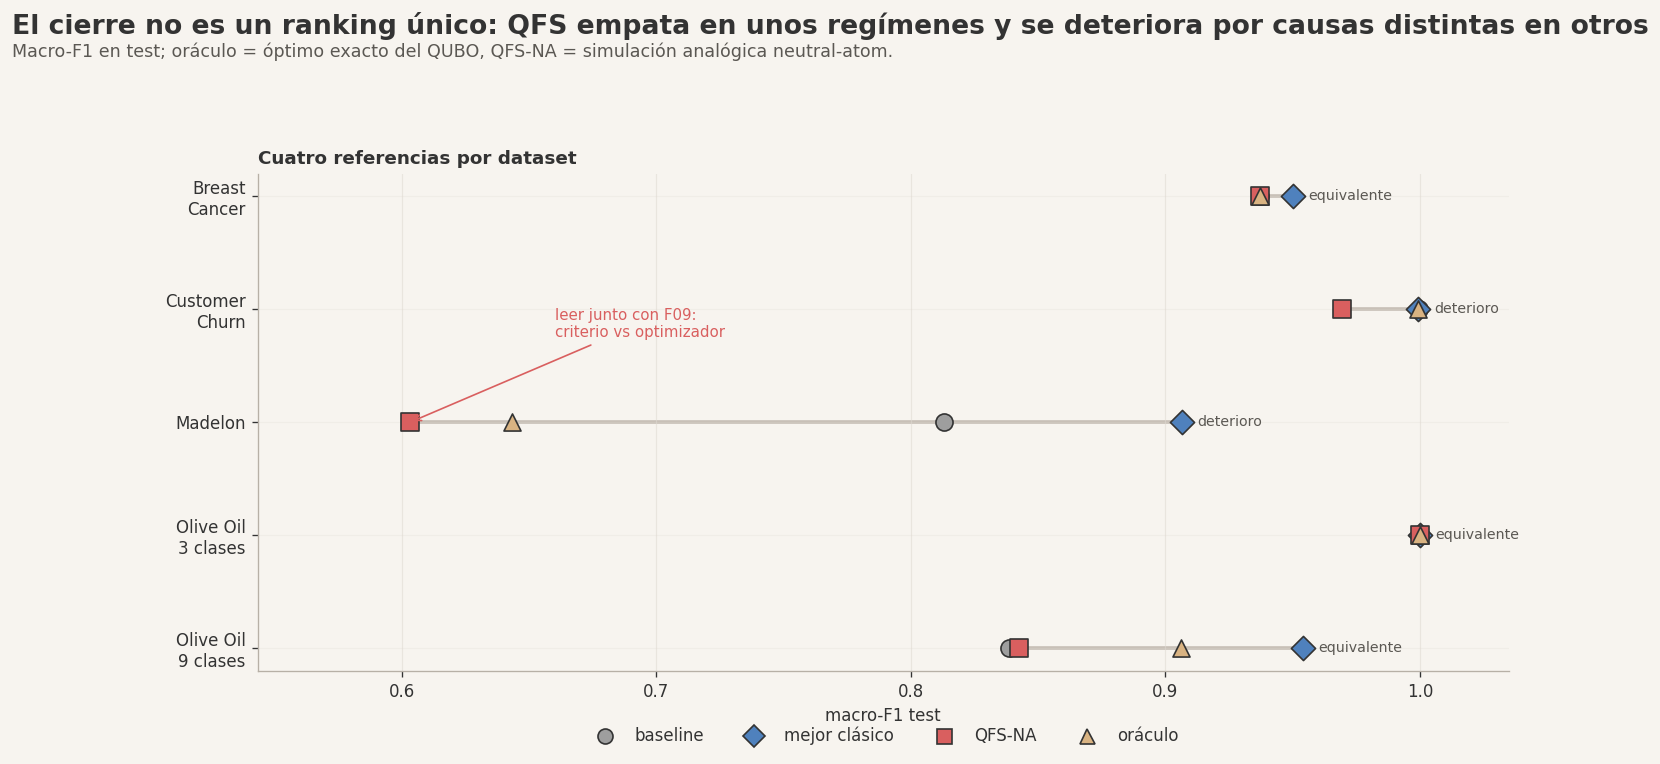

In [11]:
def figure_f10_cierre() -> None:
    classical = table("07_final_comparison/fase7_comparacion_final.csv")
    comp = table("08_quantum/comparacion_qfs_configuraciones_vs_baseline.csv")
    rows = []
    for ds in DATASETS:
        c = classical[classical["dataset"] == ds].iloc[0]
        na = comp[(comp["dataset"] == ds) & (comp["configuration"] == "qfs_na")].iloc[0]
        oracle = comp[(comp["dataset"] == ds) & (comp["configuration"] == "qfs_oracle_mucke")].iloc[0]
        rows.append(
            {
                "dataset": ds,
                "baseline": c["baseline_test_macro_f1"],
                "clasico": c["seleccion_test_macro_f1"],
                "qfs_na": na["qfs_test_macro_f1"],
                "oraculo": oracle["qfs_test_macro_f1"],
                "veredicto": na["veredicto"],
            }
        )
    df = pd.DataFrame(rows)
    order = DATASETS[::-1]
    y = np.arange(len(order))

    fig, ax = plt.subplots(figsize=(13.2, 7.4))
    add_title(
        fig,
        "El cierre no es un ranking único: QFS empata en unos regímenes y se deteriora por causas distintas en otros",
        "Macro-F1 en test; oráculo = óptimo exacto del QUBO, QFS-NA = simulación analógica neutral-atom.",
    )
    markers = {
        "baseline": ("o", "baseline"),
        "clasico": ("D", "mejor clásico"),
        "qfs_na": ("s", "QFS-NA"),
        "oraculo": ("^", "oráculo"),
    }
    for yi, ds in zip(y, order):
        r = df[df["dataset"] == ds].iloc[0]
        vals = [r[k] for k in markers]
        ax.plot([min(vals), max(vals)], [yi, yi], color="#c8c0b7", lw=2.2, zorder=1)
        for key, (mk, _) in markers.items():
            ax.scatter(r[key], yi, s=105, marker=mk, color=QCOL[key], edgecolor="#333", zorder=3)
        ax.text(max(vals) + 0.006, yi, str(r["veredicto"]), va="center", fontsize=8.5, color="#5b5853")
    ax.set_yticks(y)
    ax.set_yticklabels(ds_order_labels(order))
    ax.set_xlabel("macro-F1 test")
    xmin = max(0.0, df[list(markers)].min().min() - 0.06)
    ax.set_xlim(xmin, 1.035)
    ax.set_title("Cuatro referencias por dataset", loc="left")
    handles = [
        Line2D([0], [0], marker=mk, color="none", markerfacecolor=QCOL[key], markeredgecolor="#333", label=lab, markersize=9)
        for key, (mk, lab) in markers.items()
    ]
    ax.legend(handles=handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.18))
    ax.annotate(
        "leer junto con F09:\ncriterio vs optimizador",
        xy=(df.loc[df.dataset == "madelon", "qfs_na"].iloc[0], order.index("madelon")),
        xytext=(0.66, order.index("madelon") + 0.75),
        arrowprops=dict(arrowstyle="->", color=QCOL["negativo"]),
        color=QCOL["negativo"],
        fontsize=9,
    )
    finish_axes(ax)
    fig.subplots_adjust(top=0.80, left=0.17, right=0.96, bottom=0.24)
    save_figure(fig, "F10_comparacion_final_clasico_qfs")
    plt.show()


figure_f10_cierre()

## Inventario generado

In [12]:
generated = sorted(OUT.glob("F*.png"))
print(f"Figuras generadas: {len(generated)}")
for path in generated:
    print("-", path.relative_to(ROOT))

Figuras generadas: 10
- results/figures/superfiguras_memoria_finalistas/F01_banco_regimenes.png
- results/figures/superfiguras_memoria_finalistas/F02_senal_fdr_efecto.png
- results/figures/superfiguras_memoria_finalistas/F03_base_confiable.png
- results/figures/superfiguras_memoria_finalistas/F04_perfil_selectores.png
- results/figures/superfiguras_memoria_finalistas/F05_frontera_coste_rendimiento.png
- results/figures/superfiguras_memoria_finalistas/F06_shap_beeswarm_instancias.png
- results/figures/superfiguras_memoria_finalistas/F07_significancia_magnitud.png
- results/figures/superfiguras_memoria_finalistas/F08_mandos_qfs_alpha_beta.png
- results/figures/superfiguras_memoria_finalistas/F09_atribucion_criterio_optimizador.png
- results/figures/superfiguras_memoria_finalistas/F10_comparacion_final_clasico_qfs.png


## Auditoría visual aplicada · cuerpo y apéndice

Esta celda convierte la auditoría visual en una decisión reproducible: el
cuerpo conserva una serie breve F01-F10 y las figuras diagnósticas redundantes
pasan a respaldo/apéndice. La decisión no borra evidencia; solo evita que el
capítulo de resultados compita con demasiadas figuras a la vez.

In [13]:
BODY_MANIFEST = [
    {
        "id": "F01",
        "archivo": "F01_banco_regimenes.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Por qué los datasets deben leerse por régimen y no como un promedio único?",
        "decision": "mantener",
    },
    {
        "id": "F02",
        "archivo": "F02_senal_fdr_efecto.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Dónde hay señal estadística suficiente antes de modelar?",
        "decision": "mantener",
    },
    {
        "id": "F03",
        "archivo": "F03_base_confiable.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿El banco experimental es confiable antes de comparar métodos?",
        "decision": "mantener",
    },
    {
        "id": "F04",
        "archivo": "F04_perfil_selectores.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Qué perfil muestran los selectores clásicos?",
        "decision": "mantener",
    },
    {
        "id": "F05",
        "archivo": "F05_frontera_coste_rendimiento.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Qué métodos quedan cerca de la frontera rendimiento-coste?",
        "decision": "mantener",
    },
    {
        "id": "F06",
        "archivo": "F06_shap_beeswarm_instancias.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Qué variables explican localmente las predicciones?",
        "decision": "mantener",
    },
    {
        "id": "F07",
        "archivo": "F07_significancia_magnitud.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Las diferencias observadas son estadísticamente sostenibles?",
        "decision": "mantener",
    },
    {
        "id": "F08",
        "archivo": "F08_mandos_qfs_alpha_beta.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Cómo modifican alpha y beta el criterio QFS?",
        "decision": "mantener",
    },
    {
        "id": "F09",
        "archivo": "F09_atribucion_criterio_optimizador.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿El fallo de QFS viene del criterio o del optimizador?",
        "decision": "mantener como figura central",
    },
    {
        "id": "F10",
        "archivo": "F10_comparacion_final_clasico_qfs.png",
        "ubicacion_recomendada": "cuerpo",
        "pregunta": "¿Dónde queda QFS al cerrar la comparación por dataset?",
        "decision": "mantener",
    },
]

APPENDIX_MANIFEST = [
    {
        "id": "A01",
        "archivo": "explor_mapa_metodos.png",
        "ubicacion_recomendada": "apendice/respaldo",
        "pregunta": "¿Qué familias de métodos se probaron en la exploración?",
        "decision": "bajar: útil como inventario, no como resultado principal",
    },
    {
        "id": "A02",
        "archivo": "f10_b2_jaccard_12_metodos.png",
        "ubicacion_recomendada": "apendice/respaldo",
        "pregunta": "¿Cómo se solapan los 12 métodos clásicos?",
        "decision": "bajar: diagnóstico denso; compite con el relato principal",
    },
    {
        "id": "A03",
        "archivo": "f10_b4_escalera_alpha.png",
        "ubicacion_recomendada": "apendice/respaldo",
        "pregunta": "¿Qué barrido fino se hizo sobre alpha?",
        "decision": "bajar: detalle paramétrico ya resumido por F08",
    },
    {
        "id": "A04",
        "archivo": "f10_b5_beta_geometria.png",
        "ubicacion_recomendada": "apendice/respaldo",
        "pregunta": "¿Qué geometrías induce beta?",
        "decision": "bajar: detalle técnico ya resumido por F08",
    },
    {
        "id": "A05",
        "archivo": "f10_b8_cadena_tests.png",
        "ubicacion_recomendada": "apendice/respaldo",
        "pregunta": "¿Qué cadena completa de tests se ejecutó?",
        "decision": "bajar: trazabilidad, no conclusión visual",
    },
    {
        "id": "A06",
        "archivo": "f10_b10_consistencia.png",
        "ubicacion_recomendada": "apendice/respaldo",
        "pregunta": "¿Qué consistencia interna se observó en QFS?",
        "decision": "bajar: diagnóstico secundario",
    },
    {
        "id": "A07",
        "archivo": "ev6_rendimiento_vs_k.png",
        "ubicacion_recomendada": "apendice/respaldo opcional",
        "pregunta": "¿Cómo cambia el rendimiento con k?",
        "decision": "bajar salvo que el texto necesite discutir k explícitamente",
    },
    {
        "id": "A08",
        "archivo": "f10_b9_atomos_mds_error.png",
        "ubicacion_recomendada": "apendice/respaldo opcional",
        "pregunta": "¿Cómo se proyecta el error por configuración de átomos?",
        "decision": "bajar salvo que se use para explicar el optimizador",
    },
]

visual_manifest = pd.DataFrame(BODY_MANIFEST + APPENDIX_MANIFEST)
manifest_path = OUT / "manifest_auditoria_visual.csv"
visual_manifest.to_csv(manifest_path, index=False)
print(f"guardado: {manifest_path.relative_to(ROOT)}")
visual_manifest

guardado: results/figures/superfiguras_memoria_finalistas/manifest_auditoria_visual.csv


,id,archivo,ubicacion_recomendada,pregunta,decision
0,F01,F01_banco_regimenes.png,cuerpo,¿Por qué los datasets deben leerse por régimen...,mantener
1,F02,F02_senal_fdr_efecto.png,cuerpo,¿Dónde hay señal estadística suficiente antes ...,mantener
2,F03,F03_base_confiable.png,cuerpo,¿El banco experimental es confiable antes de c...,mantener
3,F04,F04_perfil_selectores.png,cuerpo,¿Qué perfil muestran los selectores clásicos?,mantener
4,F05,F05_frontera_coste_rendimiento.png,cuerpo,¿Qué métodos quedan cerca de la frontera rendi...,mantener
5,F06,F06_shap_beeswarm_instancias.png,cuerpo,¿Qué variables explican localmente las predicc...,mantener
6,F07,F07_significancia_magnitud.png,cuerpo,¿Las diferencias observadas son estadísticamen...,mantener
7,F08,F08_mandos_qfs_alpha_beta.png,cuerpo,¿Cómo modifican alpha y beta el criterio QFS?,mantener
8,F09,F09_atribucion_criterio_optimizador.png,cuerpo,¿El fallo de QFS viene del criterio o del opti...,mantener como figura central
9,F10,F10_comparacion_final_clasico_qfs.png,cuerpo,¿Dónde queda QFS al cerrar la comparación por ...,mantener


## Lámina de respaldo/apéndice

La siguiente figura no sustituye a las fuentes originales: sirve como tablero
de revisión dentro del notebook para comprobar qué material visual queda fuera
del cuerpo principal.

guardado: results/figures/superfiguras_memoria_finalistas/A00_figuras_respaldo_apendice.png


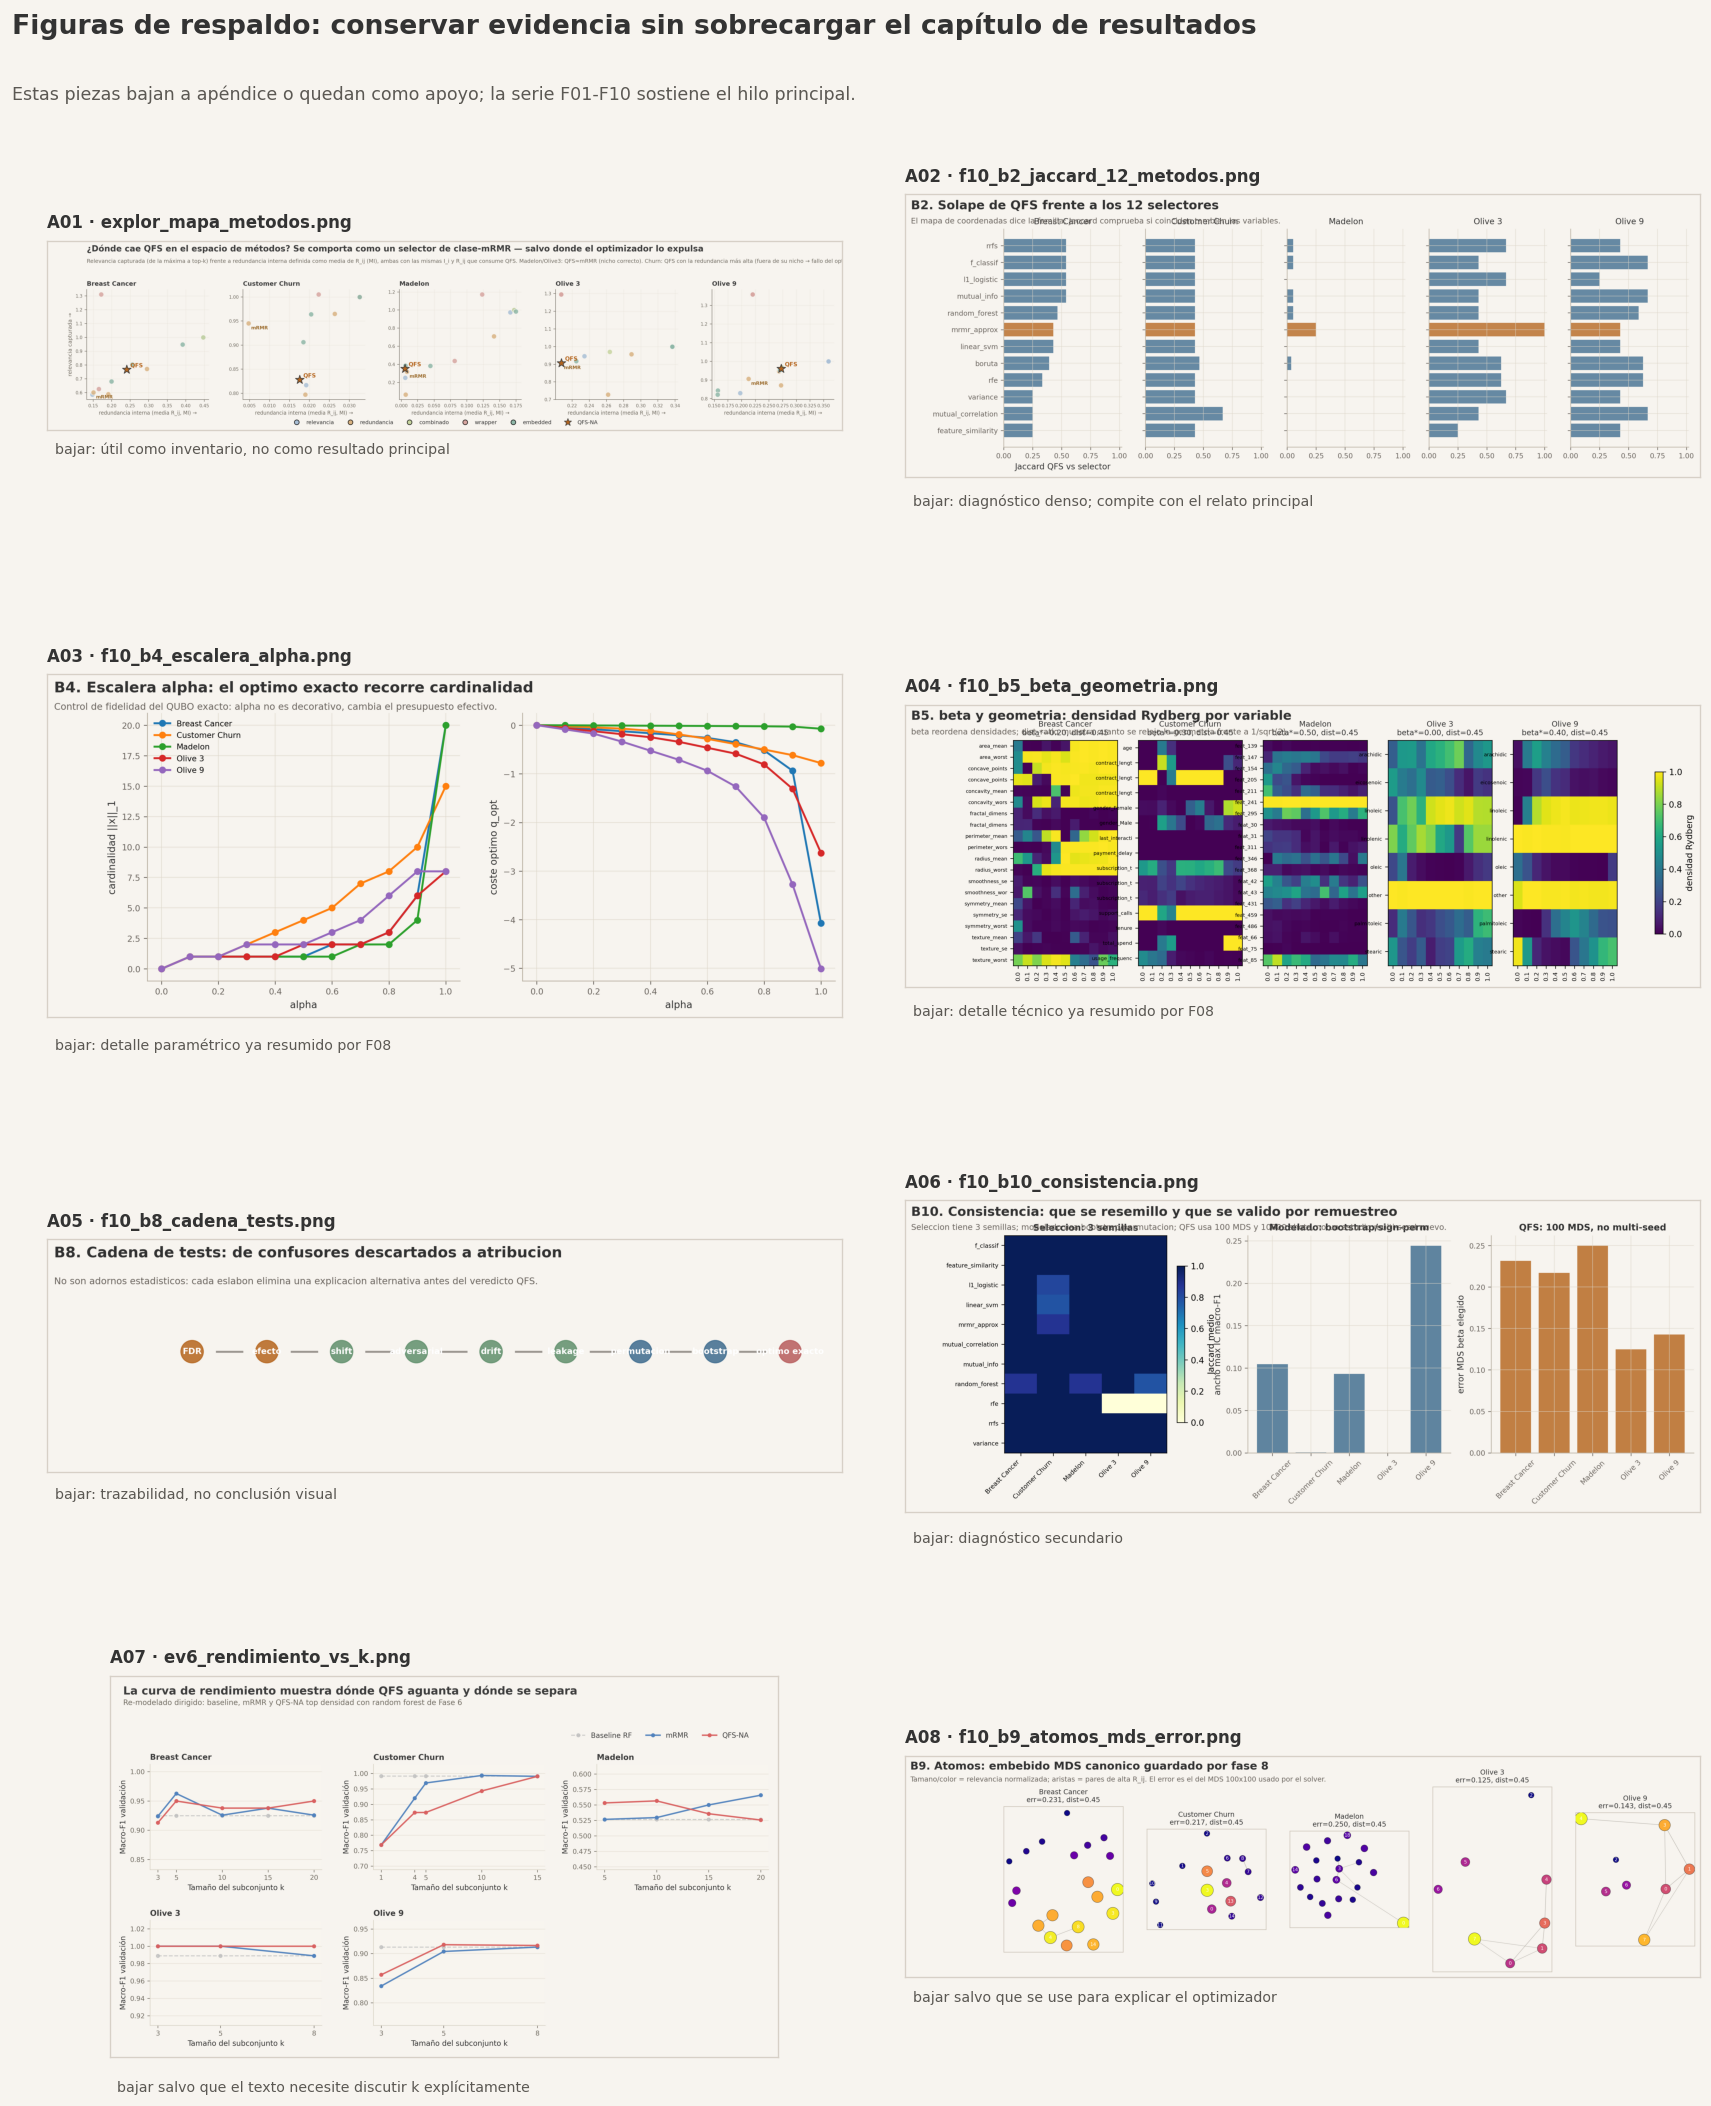

In [14]:
def figure_a00_respaldo_apendice() -> None:
    items = APPENDIX_MANIFEST
    fig, axes = plt.subplots(4, 2, figsize=(14.5, 18.0))
    axes = axes.ravel()
    add_title(
        fig,
        "Figuras de respaldo: conservar evidencia sin sobrecargar el capítulo de resultados",
        "Estas piezas bajan a apéndice o quedan como apoyo; la serie F01-F10 sostiene el hilo principal.",
    )

    for ax, item in zip(axes, items):
        path = MEMORIA_FIGS / item["archivo"]
        ax.set_facecolor("#fbf8f2")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("#d7d0c7")

        title = f"{item['id']} · {item['archivo']}"
        ax.set_title(title, loc="left", fontsize=10, fontweight="bold", pad=8)
        if path.exists():
            img = plt.imread(path)
            ax.imshow(img)
        else:
            ax.text(
                0.5,
                0.58,
                "archivo no encontrado",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color=QCOL["negativo"],
            )
            ax.text(
                0.5,
                0.43,
                str(path.relative_to(ROOT)),
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=8,
                color="#5b5853",
                wrap=True,
            )
        ax.text(
            0.01,
            -0.06,
            item["decision"],
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
            color="#5b5853",
            wrap=True,
        )

    for ax in axes[len(items):]:
        ax.axis("off")

    fig.subplots_adjust(top=0.92, left=0.035, right=0.985, bottom=0.035, hspace=0.34, wspace=0.08)
    save_figure(fig, "A00_figuras_respaldo_apendice")
    plt.show()


figure_a00_respaldo_apendice()